# 心臟衰竭預測資料集（預測心臟病事件的11個臨床特徵）
https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

In [1]:
# ========== Homework 3 ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
url = "https://raw.githubusercontent.com/jayachandru001/Heart-Failure-Prediction-/main/heart.csv"
df = pd.read_csv(url)

print("--- 資料基本資訊 ---")
print(df.info())

print("---數值型特徵統計概覽(Numerical Summary)---")
display(df.describe().T)

print("\n---類別型特徵樣態掃描(Categorical/Object Modality)---")
object_summary = []
for col in df.select_dtypes(include=['object']).columns:
    object_summary.append({
        "欄位名稱": col,
        "樣態數量": df[col].nunique(),
        "具體樣態內容": df[col].unique().tolist(),
        "最頻繁樣態 (Mode)": df[col].mode()[0]
    })

df_obj_scan = pd.DataFrame(object_summary)
display(df_obj_scan)

print(f"\n資料集維度：{df.shape[0]} 筆觀測值, {df.shape[1]} 個特徵欄位")

--- 資料基本資訊 ---
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None
---數值型特徵統計概覽(Numerical Summary)---


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0



---類別型特徵樣態掃描(Categorical/Object Modality)---


C:\Users\yello\AppData\Local\Temp\ipykernel_50412\2547292415.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,欄位名稱,樣態數量,具體樣態內容,最頻繁樣態 (Mode)
0,Sex,2,"[M, F]",M
1,ChestPainType,4,"[ATA, NAP, ASY, TA]",ASY
2,RestingECG,3,"[Normal, ST, LVH]",Normal
3,ExerciseAngina,2,"[N, Y]",N
4,ST_Slope,3,"[Up, Flat, Down]",Flat



資料集維度：918 筆觀測值, 12 個特徵欄位


**資料基本資訊**
*   資料筆數與完整度：RangeIndex: 918 entries=>總共有918位病患的資料，經初步檢視資料集無缺失值，不需進行插補或刪除欄位
*   dtypes：float64(1),int64(6)=>有7個欄位是數字型態
*   dtypes：object(5)=>有5個欄位是字串/類別型態，後續使用pd.get_dummies將這5個object欄位轉換成0與1

**數值描述統計**
*   HeartDisease(Lable)的mean(平均值)：0.553377，平均值是0.55，代表這918人之中，大約有 55%的人有心臟病，45%的人沒有，資料分佈算是平衡的，模型在學習時不會偏袒任何一方
*   RestingBP(靜止血壓)和Cholesterol(膽固醇)的min兩者的最小值都是0，活著的病患血壓和膽固醇絕對不可能是0，我們推測可能是資料登錄錯誤或缺失。為了避免誤導模型，在預處理時會將這些0視為異常值，用中位數填補
*   Cholesterol的max可以高達603，但Oldpeak的範圍只在-2.6到6.2之間，所以要做StandardScaler


# 資料集欄位（中英文）
*   年齡*Age*
*   性別*Sex*
*   胸痛類型*ChestPainType*
*   靜止血壓*RestingBP*
*   膽固醇*Cholesterol*
*   空腹血糖*FastingBS*（0：代表空腹血糖正常（<120）。1：代表空腹血糖異常（>120）
*   靜止心電圖*RestingECG*
*   最大心率*MaxHR*
*   運動性心絞痛*ExerciseAngina*
*   ST段下降的程度*Oldpeak*
*   ST_斜率*ST_Slope*
*   心臟病*HeartDisease*


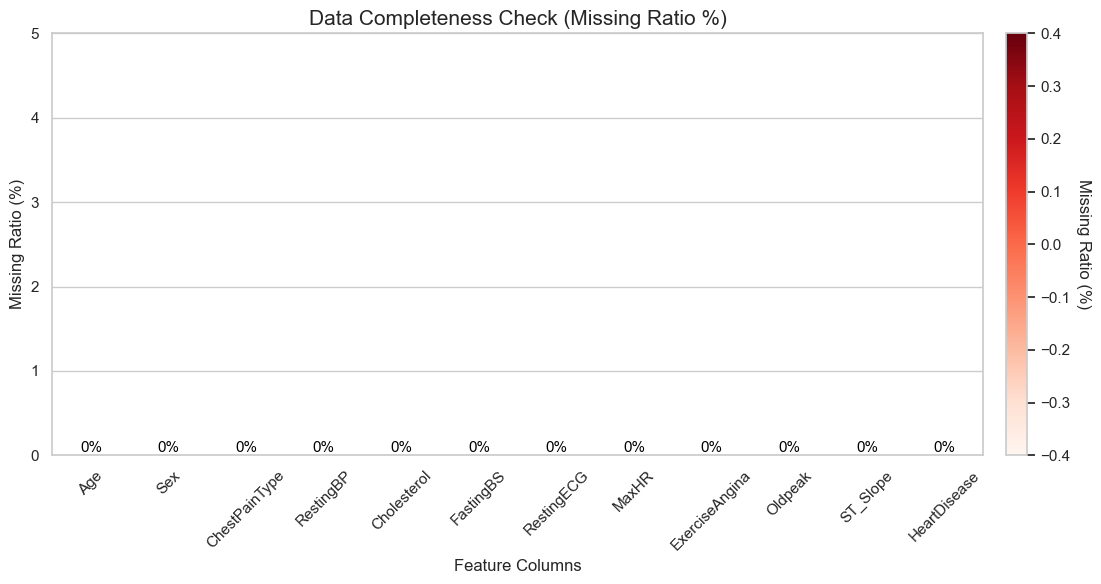


---類別型特徵分析圖---


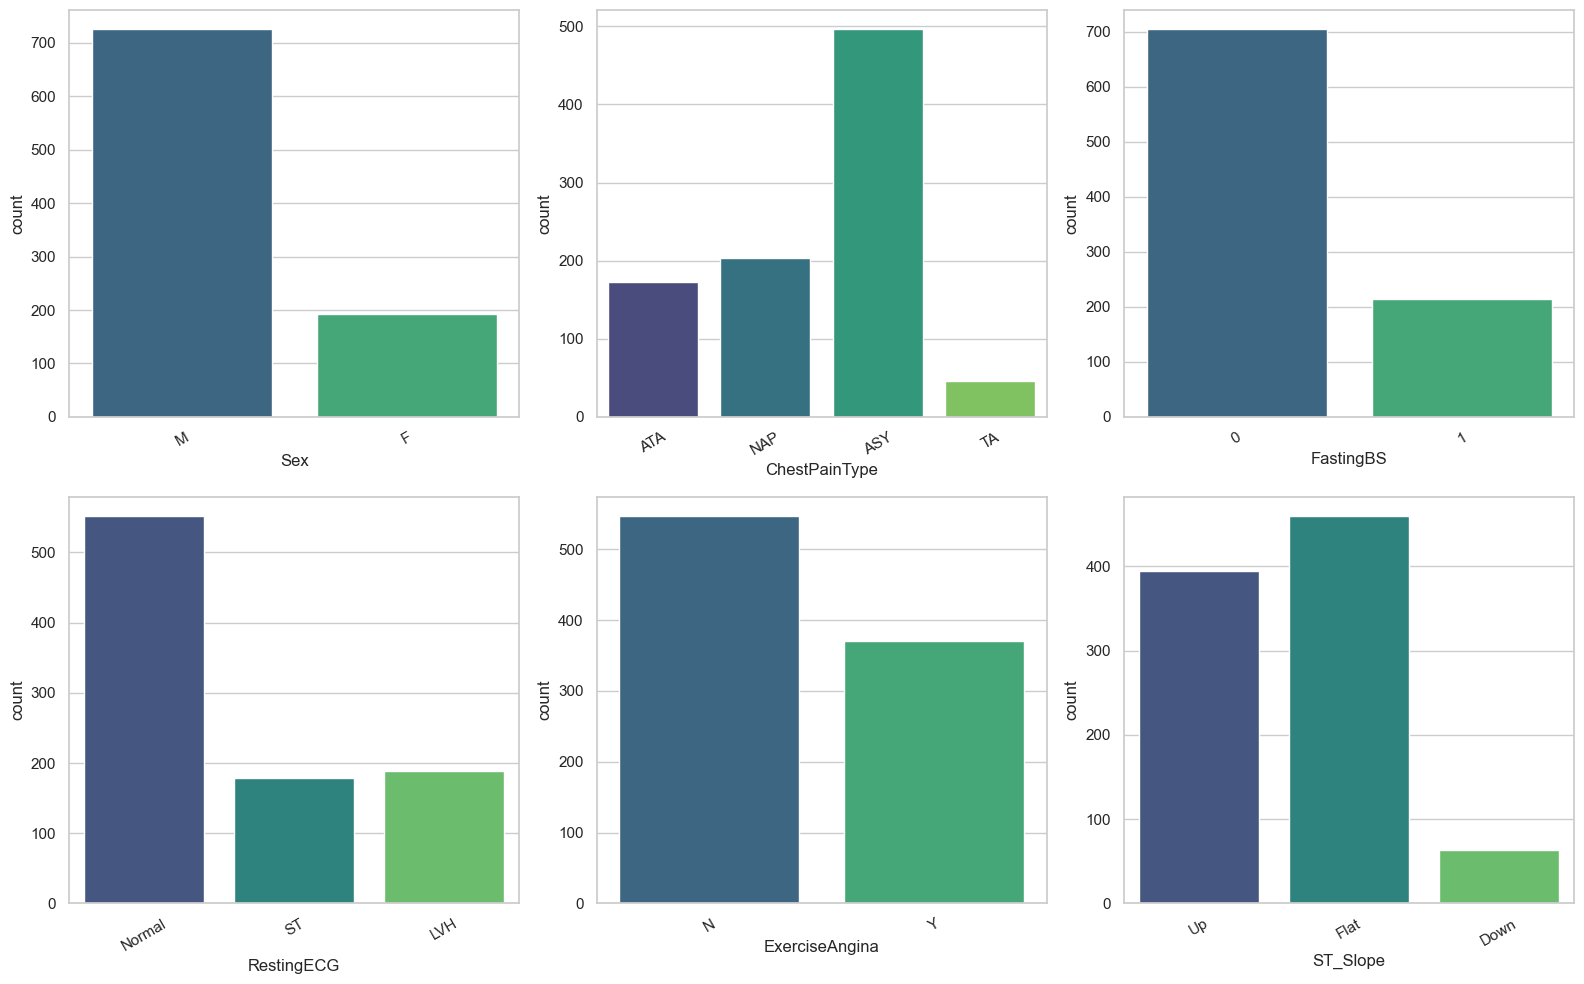


---數值型特徵分析圖---


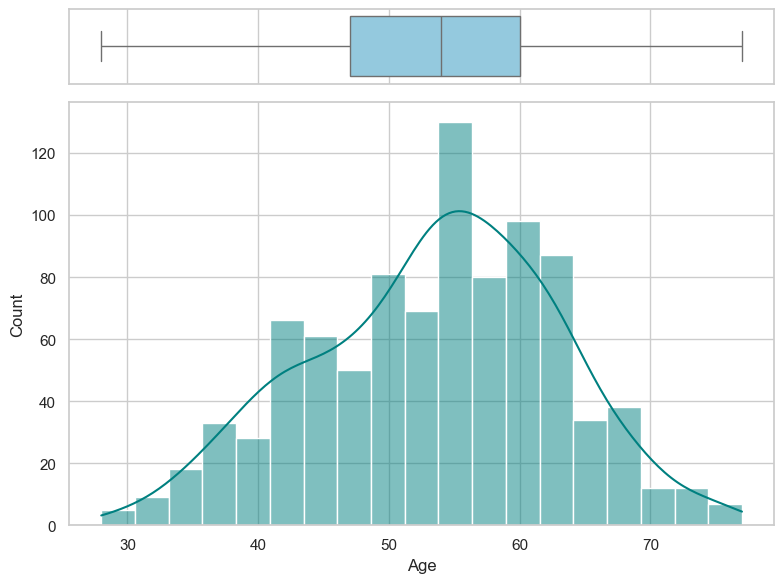

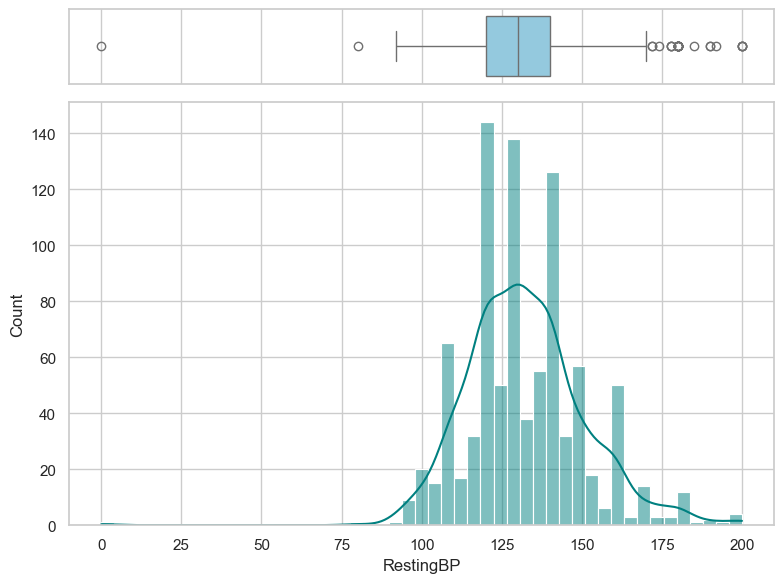

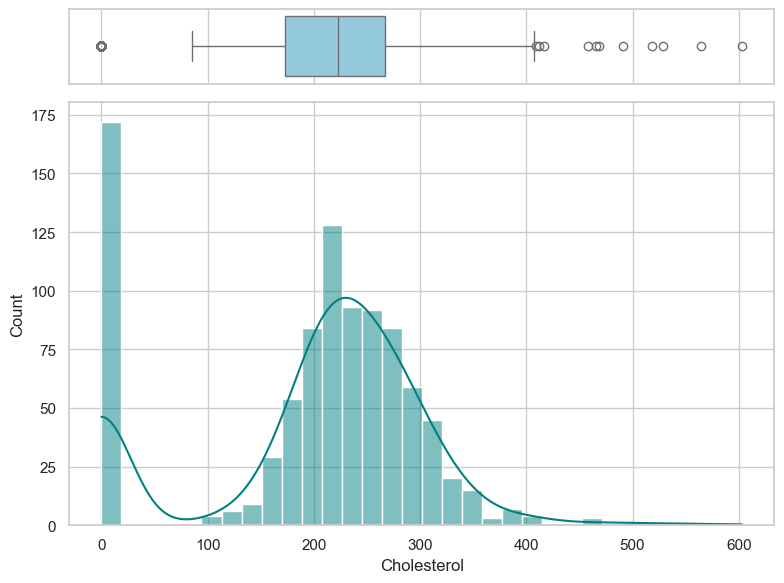

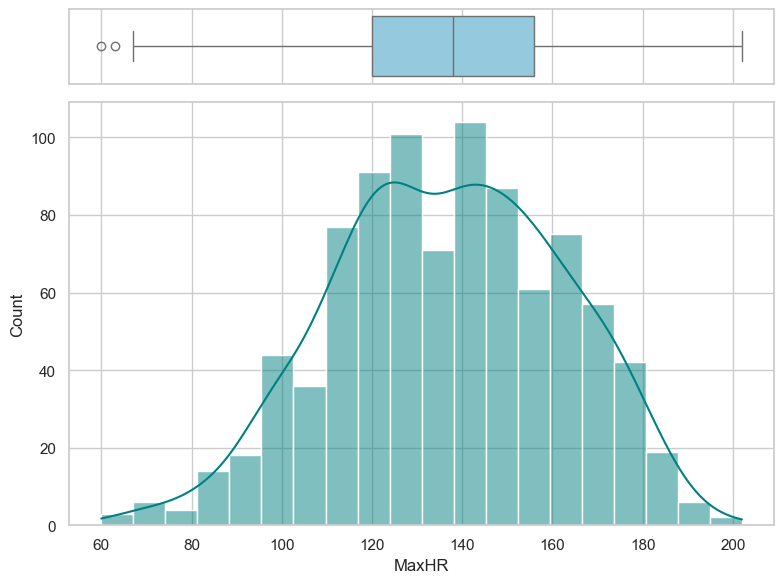

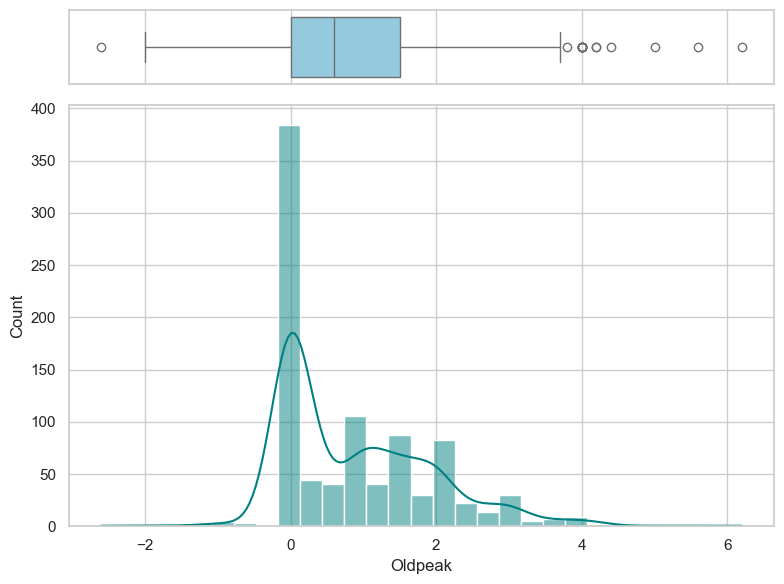

In [2]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable

sns.set_theme(style="whitegrid")

#分類特徵群組(包含全部 11 個參數)
#雖然FastingBS是數字（0或1），但在醫療資料集中，它通常被視為類別型(0:血糖正常（<120mg/dL）;1:代表血糖異常（>120 mg/dL）)
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

#數據完整性檢查

#計算缺失值比例
missing_data = df.isnull().mean() * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Ratio': missing_data.values})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Feature', y='Ratio', data=missing_df, hue='Feature', palette='Reds_r', ax=ax)
legend = ax.get_legend()
if legend:
    legend.remove()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

sm = ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=-0.4, vmax=0.4))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Missing Ratio (%)', rotation=270, labelpad=15)

ax.set_title('Data Completeness Check (Missing Ratio %)', fontsize=15)
ax.set_ylabel('Missing Ratio (%)')
ax.set_xlabel('Feature Columns')
ax.set_ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#類別型特徵分析
print("\n---類別型特徵分析圖---")
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


#數值型特徵分析
print("\n---數值型特徵分析圖---")
for col in numerical_features:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8, 6))

    sns.boxplot(x=df[col], ax=ax_box, color="skyblue")
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color="teal")

    ax_box.set(xlabel='')
    plt.tight_layout()
    plt.show()

**膽固醇分佈(Cholesterol Distribution)**
*   最左邊數值為0的地方，有一根超過150筆資料的長條，而右邊100~400之間則呈現一個正常的鐘型曲線
*   透過直方圖檢視膽固醇分佈，我們發現有超過150筆異常的0。若直接將其餵給模型，會嚴重扭曲特徵空間。因此我們在預處理會針對這些0進行修正（替換為中位數）













# 資料預處理 (清洗、編碼與正規化)
資料集有很多字串型的類別資料（例如性別M/F、胸痛類型ATA/NAP）
先處理EDA階段發現的異常值0，再做One-Hot Encoding、再把數值型資料（如年齡、膽固醇）進行正規化 (Normalization)

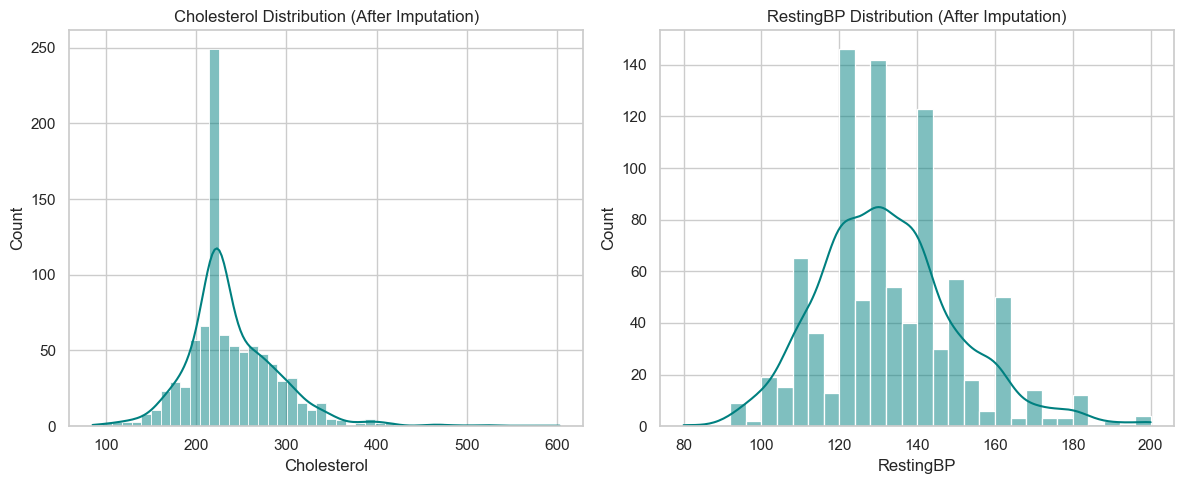

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 異常值清洗
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

# 清洗後分佈確認
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Cholesterol'], kde=True, color='teal')
plt.title('Cholesterol Distribution (After Imputation)')

plt.subplot(1, 2, 2)
sns.histplot(df['RestingBP'], kde=True, color='teal')
plt.title('RestingBP Distribution (After Imputation)')
plt.tight_layout()
plt.show()



*   消除了極端異常點對平均值的拉扯，使數據分佈回歸常態，確保模型不會被錯誤數據誤導





C:\Users\yello\AppData\Local\Temp\ipykernel_50412\1978657005.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_heatmap_temp.select_dtypes(include=['object']).columns:


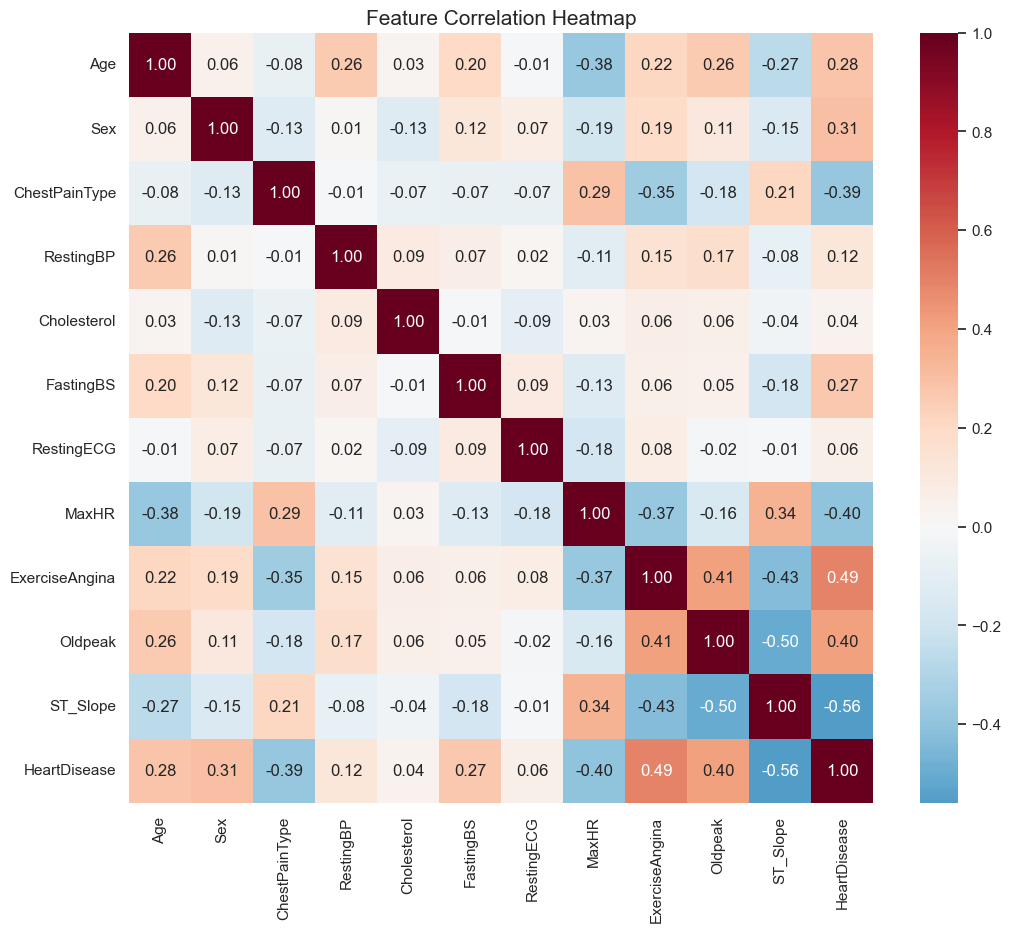

In [4]:
# 關聯性熱圖
df_heatmap_temp = df.copy()
for col in df_heatmap_temp.select_dtypes(include=['object']).columns:
    df_heatmap_temp[col] = df_heatmap_temp[col].astype('category').cat.codes

plt.figure(figsize=(12, 10))
sns.heatmap(df_heatmap_temp.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.show()


類別型特徵對患病機率的影響


C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='HeartDisease', palette='viridis', capsize=.1)
C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='HeartDisease', palette='viridis', capsize=.1)
C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='HeartDisease', palette='viridis', capsize=.1)
C:\Users\yello\A

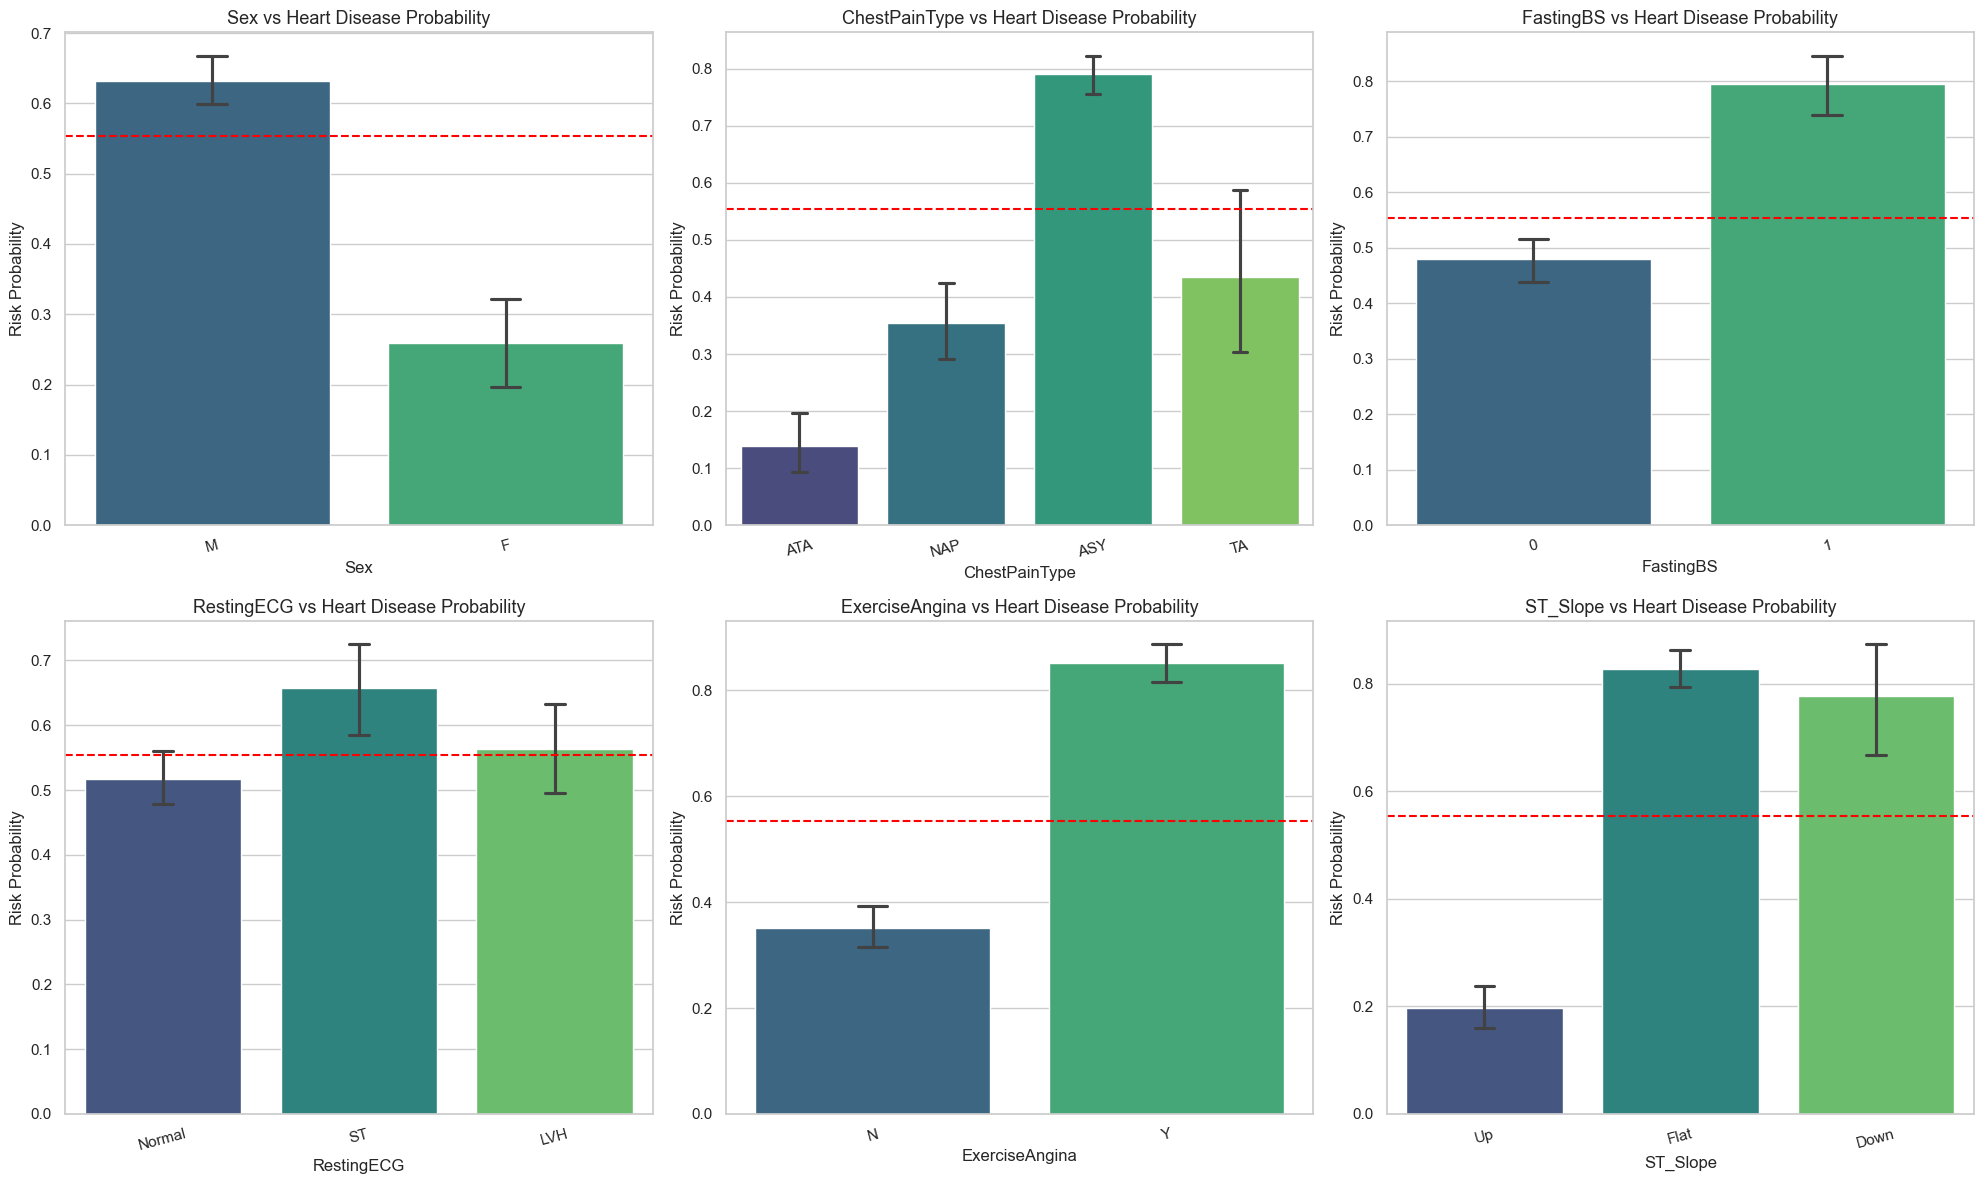


數值型特徵之分佈


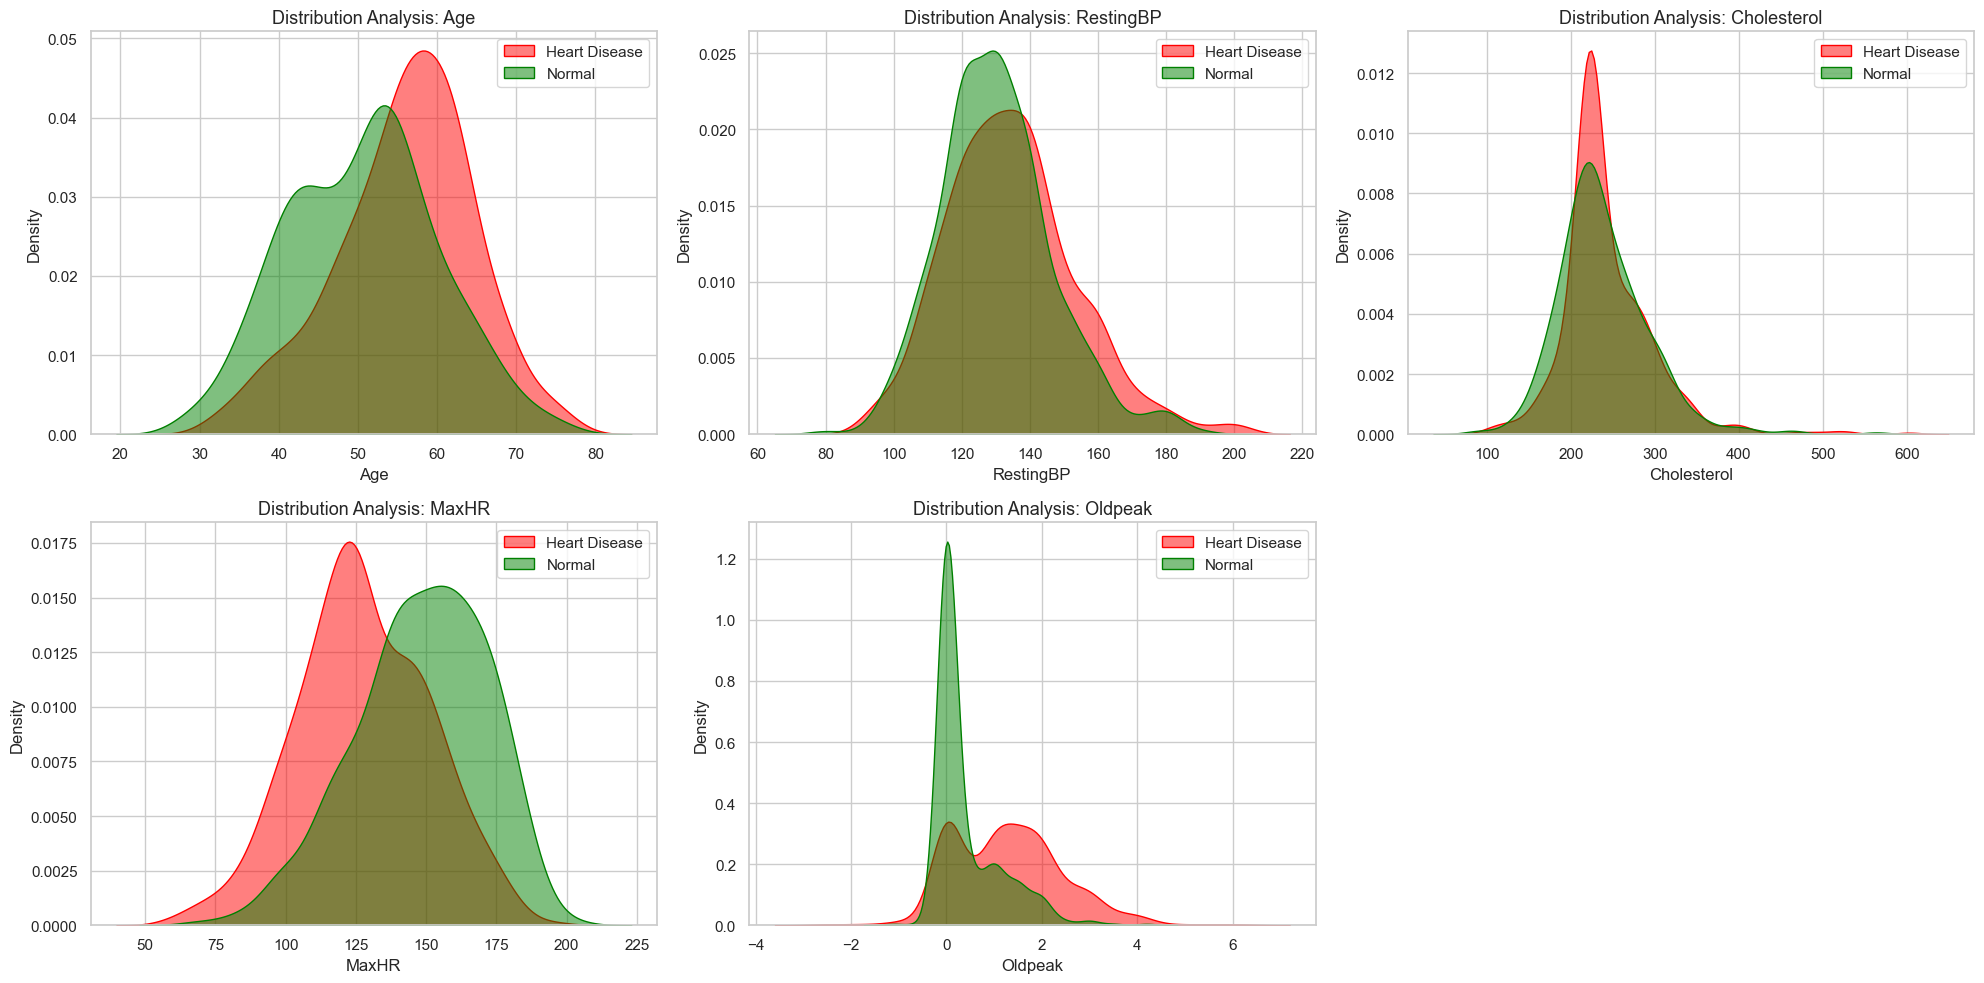

C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette='RdYlGn')
C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette='RdYlGn')
C:\Users\yello\AppData\Local\Temp\ipykernel_50412\424273851.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette='RdYlGn')
C:\Users\yello\AppData\Local\Temp\ipykernel_50412\42

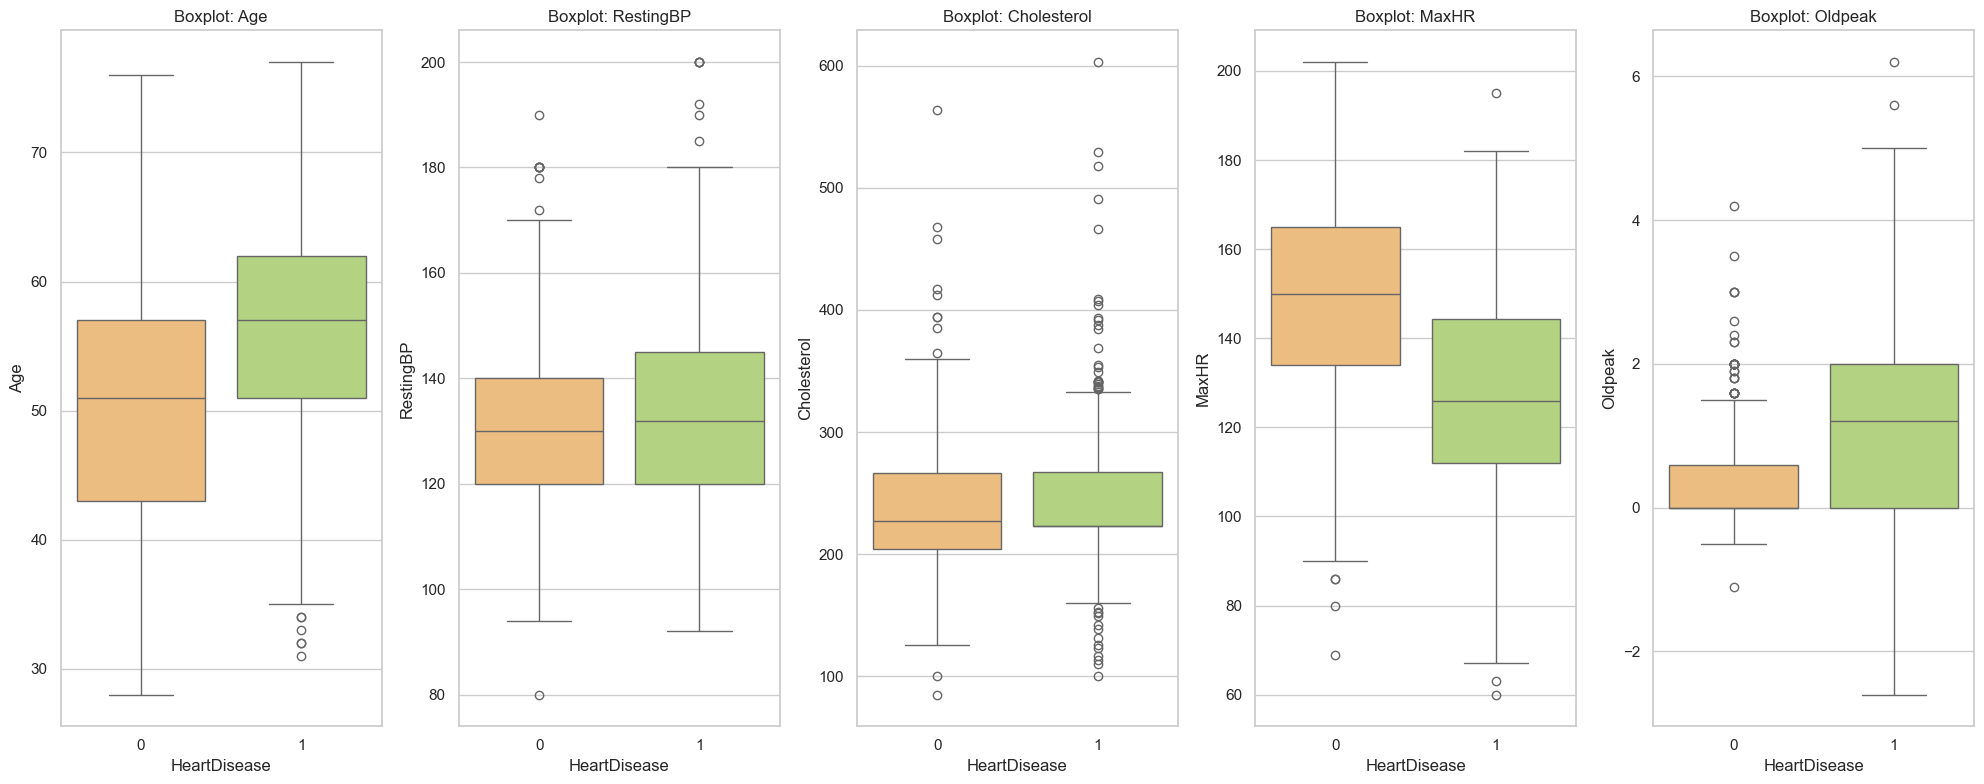

In [5]:
#類別型特徵與心臟病關係分析 (分析患病機率/比例)
print("\n類別型特徵對患病機率的影響")

plt.figure(figsize=(20, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.barplot(data=df, x=col, y='HeartDisease', palette='viridis', capsize=.1)

    #加入全體平均患病基準線
    plt.axhline(df['HeartDisease'].mean(), color='red', linestyle='--', label='Average Risk')

    plt.title(f'{col} vs Heart Disease Probability', fontsize=13)
    plt.ylabel('Risk Probability')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#數值型特徵與心臟病關係分析(分析數據分佈差異)
print("\n數值型特徵之分佈")

plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df[df['HeartDisease'] == 1], x=col, fill=True, label='Heart Disease', color='red', alpha=0.5)
    sns.kdeplot(data=df[df['HeartDisease'] == 0], x=col, fill=True, label='Normal', color='green', alpha=0.5)

    plt.title(f'Distribution Analysis: {col}', fontsize=13)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(20, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=df, x='HeartDisease', y=col, palette='RdYlGn')
    plt.title(f'Boxplot: {col}', fontsize=12)

plt.tight_layout()
plt.show()

**1. 類別型特徵：患病風險機率分析 (Barplots)**

*   ST_Slope (Flat/Down)：這兩者的患病比例高達 80%，遠超紅色虛線（平均水平）。這證明了心電圖斜率是判斷心臟衰竭最大的特徵

*   ExerciseAngina (Y)：運動引發心絞痛的人，患病機率接近 85%

*   ChestPainType (ASY)：雖然名為「無症狀」，但其發病率是所有胸痛類型中最高的（接近 80%）

*   性別差異：男性的患病風險（約63%）顯著高於女性（約25%）

*   血糖影響：FastingBS 為 1（空腹血糖異常）的人群，患病機率也明顯高於血糖正常者

**2. 數值型特徵：數據分佈與密度分析 (KDE Plots)**

**顯著區分力（峰值偏移）：MaxHR、Age**
*   MaxHR (最大心率)：健康者的綠色峰值偏右（心率較高），患病者的紅色峰值明顯偏左。這代表低的最大心率跟心臟病有關

*   Age (年齡)：紅色曲線（患病）的重心明顯比綠色更靠右

**低區分力（高度重疊）：Cholesterol**
*   靜止血壓RestingBP：RestingBP的相關係數只有0.12。在120-130的正常血壓區間，兩組的人數都非常多且分佈一致，單靠血壓這一個指標很難區分出誰有病
*   Cholesterol (膽固醇)：兩條曲線幾乎重疊。這解釋了為什麼在熱圖中它的相關係數只有0.04，代表它在線性區分上有難度，需要模型進行更複雜的非線性學習

**Oldpeak (ST段下降)：健康者幾乎全部堆積在0，而患病者在1~4之間有第二個明顯的波峰**

**3. 數值型特徵：離群值與集中趨勢分析 (Boxplots)**
*   中位數差異：在MaxHR、Oldpeak和Age中，兩組的Box位置有明顯的落差，代表這些特徵有高預測價值
*   離群值 (Outliers)：Cholesterol和RestingBP存在不少圈圈（離群點）。這告訴我們數據存在一定的極端值，這也是為什麼我們必須使用StandardScaler的原因

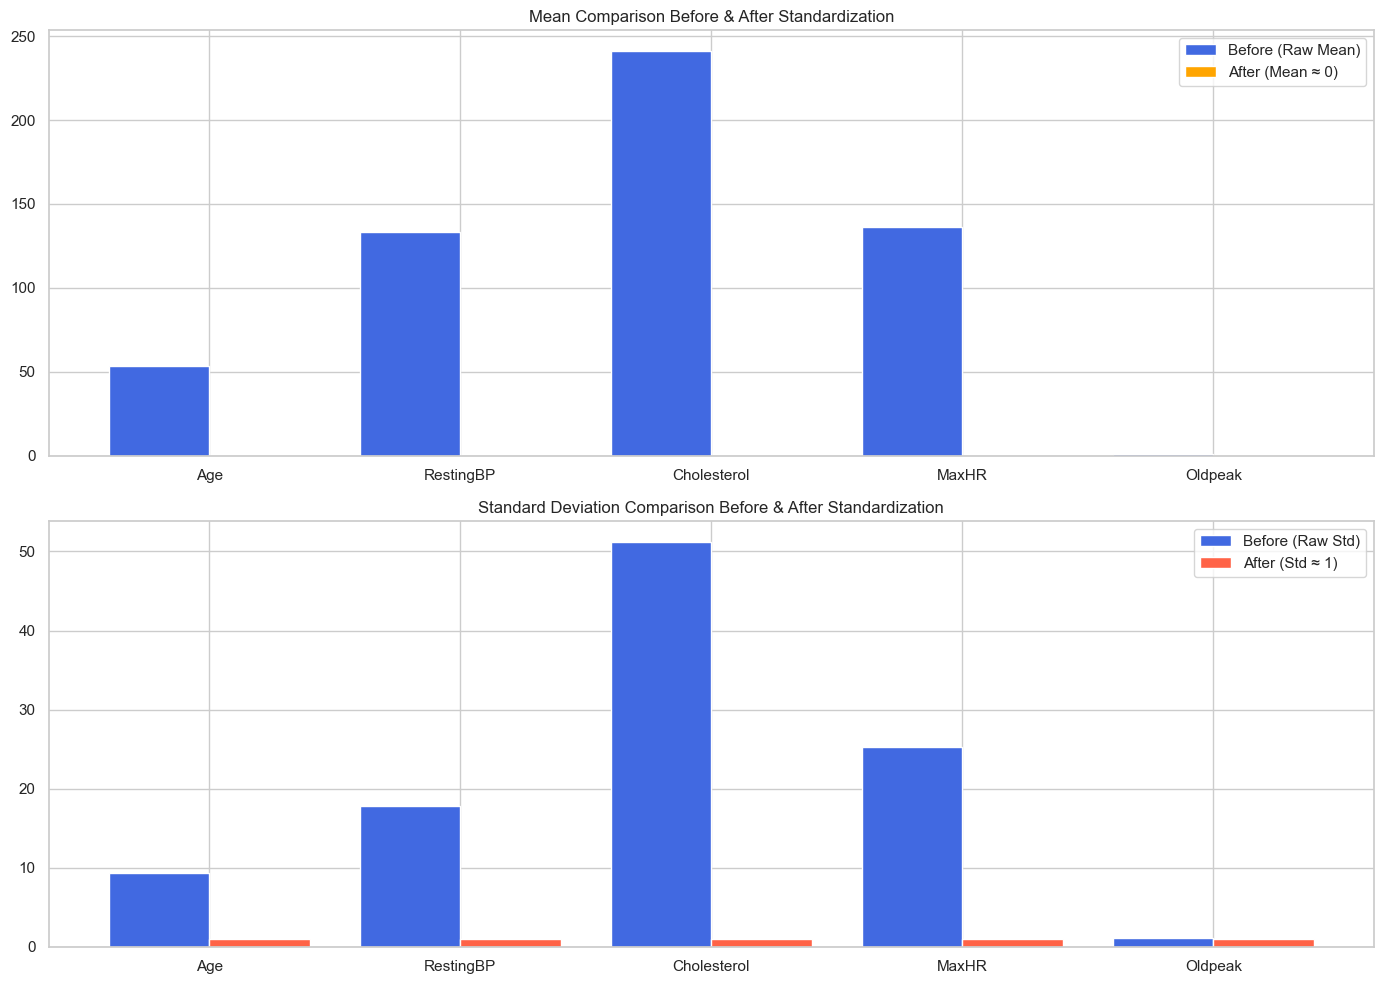


--- 特徵處理與正規化完成 ---
原始特徵數: 12
編碼後建模特徵總數: 15


In [6]:
# One-Hot 編碼 (為了建模穩定性，建議設 drop_first=True)
df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=True)

#定義特徵矩陣 X 與目標變數 y
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

#切分訓練集與測試集 (80/20 分配)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#StandardScaler
X_train_before = X_train[numerical_features].copy()

scaler = StandardScaler()

# 對訓練集進行 fit_transform，對測試集僅進行 transform
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

#StandardScaler前後比對圖
plt.figure(figsize=(14, 10))

# 觀察中心點是否成功移至 0
plt.subplot(2, 1, 1)
means_before = X_train_before.mean()
means_after = X_train[numerical_features].mean()
x_axis = np.arange(len(numerical_features))

plt.bar(x_axis - 0.2, means_before, 0.4, label='Before (Raw Mean)', color='royalblue')
plt.bar(x_axis + 0.2, means_after, 0.4, label='After (Mean ≈ 0)', color='orange')
plt.xticks(x_axis, numerical_features)
plt.title('Mean Comparison Before & After Standardization')
plt.legend()

# 標準差對比：觀察尺度是否成功統一為 1
plt.subplot(2, 1, 2)
std_before = X_train_before.std()
std_after = X_train[numerical_features].std()

plt.bar(x_axis - 0.2, std_before, 0.4, label='Before (Raw Std)', color='royalblue')
plt.bar(x_axis + 0.2, std_after, 0.4, label='After (Std ≈ 1)', color='tomato')
plt.xticks(x_axis, numerical_features)
plt.title('Standard Deviation Comparison Before & After Standardization')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- 特徵處理與正規化完成 ---")
print(f"原始特徵數: {df.shape[1]}")
print(f"編碼後建模特徵總數: {X_train.shape[1]}")



*   正規化後橘色柱子皆為0
*   正規化後標準差每一根的高度都精準地整齊排列在 1



# 模型訓練與性能基準測試(Model Training & Baseline Testing)
**決策樹選擇動機**
1.   符合醫療邏輯：決策樹的「若A則B」判斷方式與醫師診斷流程相似，能直觀呈現生理特徵（如：ST_Slope）的篩選順序
2.   擅長處理類別資料：心臟病數據包含大量Sex、ChestPainType等非連續性的類別資料，理論上樹狀模型更擅長處理這種分段式的邏輯判斷
3.   互補與穩定性驗證：為了修正決策樹容易Overfitting的缺點，我們透過GridSearchCV尋找最佳參數，同時引入邏輯回歸作為對照，驗證數據是否存在強大的線性規律，確保預測結果在精確度與穩定性之間取得平衡

**邏輯回歸選擇動機**
1.   作為對照組：決策樹雖然強大，但容易因為資料細微變動而產生Overfitting。邏輯回歸作為線性模型，其結構相對穩定，可以讓我們確認決策樹跑出來的高分是不是在死背數據
2.   驗證數據的線性特質：醫學數據中，許多指標（如血壓、心率、年齡）對風險的影響往往是累加性質的。引入邏輯回歸能幫助我們驗證這份數據到底是靠複雜的邏輯判斷贏，還是靠簡單的線性加總更準






In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# 建立基準模型(Baseline Model)
# 使用預設參數的單一決策樹，觀察模型在未受限制下的自然學習狀態與複雜度極限
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)


# 建立優化模型(Optimized Model)
# 觀察到基準模型有Overfitting的傾向，因此引入隨機森林 (Ensemble)與預剪枝 (max_depth=5)策略來限制複雜度並提升泛化能力。
rf_improved = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_improved.fit(X_train, y_train)

print("--- 基準模型：單一決策樹 ---")
print(f"訓練集準確率: {accuracy_score(y_train, tree_baseline.predict(X_train)):.4f}")
print(f"測試集準確率: {accuracy_score(y_test, tree_baseline.predict(X_test)):.4f}")

print("\n--- 優化模型：隨機森林 ---")
print(f"訓練集準確率: {accuracy_score(y_train, rf_improved.predict(X_train)):.4f}")
print(f"測試集準確率: {accuracy_score(y_test, rf_improved.predict(X_test)):.4f}")

--- 基準模型：單一決策樹 ---
訓練集準確率: 1.0000
測試集準確率: 0.7935

--- 優化模型：隨機森林 ---
訓練集準確率: 0.8910
測試集準確率: 0.8424


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#決策樹(Baseline)
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)

#優化後的決策樹(Optimized via Grid Search)
#建立參數網格，窮舉所有可能，找出不讓模型死背的最佳限制
tree_params = {
    'criterion': ['entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': [None, 'balanced']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)
grid_tree.fit(X_train, y_train)
tree_optimized = grid_tree.best_estimator_



#邏輯回歸 (Logistic Regression)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

#性能評估比較
results = {
    "未優化決策樹": tree_baseline,
    "優化後決策樹 (GridSearch)": tree_optimized,
    "邏輯回歸 (Logistic Regression)": log_reg
}

print("--- 模型對比實驗結果 ---")
for name, model in results.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"\n[{name}]")
    if "GridSearch" in name:
        print(f"最佳參數: {grid_tree.best_params_}")
    print(f"訓練集準確率: {train_acc:.4f}")
    print(f"測試集準確率: {test_acc:.4f}")
    print(f"泛化差距 (Gap): {abs(train_acc - test_acc):.4f}")

--- 模型對比實驗結果 ---

[未優化決策樹]
訓練集準確率: 1.0000
測試集準確率: 0.7935
泛化差距 (Gap): 0.2065

[優化後決策樹 (GridSearch)]
最佳參數: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
訓練集準確率: 0.8856
測試集準確率: 0.7663
泛化差距 (Gap): 0.1193

[邏輯回歸 (Logistic Regression)]
訓練集準確率: 0.8638
測試集準確率: 0.8587
泛化差距 (Gap): 0.0051


*   解決Overfitting：未優化決策樹雖有1.0的訓練準確率，但泛化差距高達0.20，明顯僅是死背數據。優化後透過GridSearch限制樹深（max_depth=5），成功將差距縮小至0.11，使模型從機械記憶轉向規律學習

*   數據特徵契合度：實驗發現邏輯回歸（Logistic Regression）表現最為卓越，測試準確率達0.8587，且泛化差距近乎為零（0.0051）。這證明心臟病數據具備強大的線性可分性，且線性模型在小樣本、高維度（One-Hot後）的場景下更具穩健性

*   雖然預期決策樹更適合處理非連續資料，但實驗發現邏輯回歸的泛化表現更穩。這證明了本數據集的特徵（如血壓、心率等）對風險的影響更傾向於線性加總，而非複雜的非線性組合

# 模型詳細評估與 ROC 曲線

=== 各模型詳細評估報告 ===

[Baseline Tree]
              precision    recall  f1-score   support

           0     0.7294    0.8052    0.7654        77
           1     0.8485    0.7850    0.8155       107

    accuracy                         0.7935       184
   macro avg     0.7889    0.7951    0.7905       184
weighted avg     0.7987    0.7935    0.7946       184


[Optimized Tree]
              precision    recall  f1-score   support

           0     0.6735    0.8571    0.7543        77
           1     0.8721    0.7009    0.7772       107

    accuracy                         0.7663       184
   macro avg     0.7728    0.7790    0.7657       184
weighted avg     0.7890    0.7663    0.7676       184


[Logistic Regression]
              precision    recall  f1-score   support

           0     0.8000    0.8831    0.8395        77
           1     0.9091    0.8411    0.8738       107

    accuracy                         0.8587       184
   macro avg     0.8545    0.8621    0.8566       18

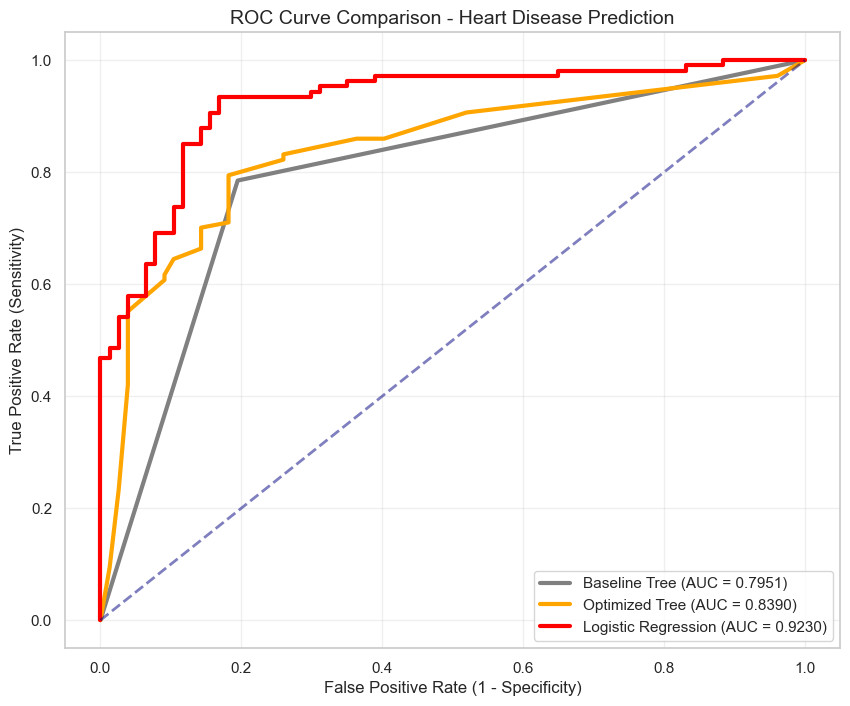

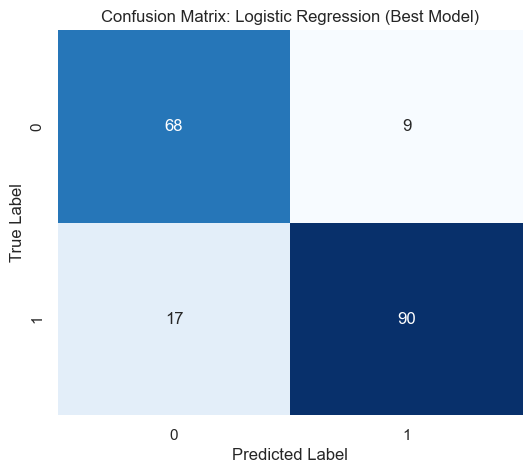

左上：TN，正確預測健康
右上：FP，誤診（沒病預測成有病）。
左下：FN，漏診（有病預測成沒病）
右下：TP，正確預測患病


In [9]:
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 定義要評估的模型清單
final_models = {
    "Baseline Tree": tree_baseline,
    "Optimized Tree": tree_optimized,
    "Logistic Regression": log_reg
}

plt.figure(figsize=(10, 8))
colors = ['gray', 'orange', 'red'] # 灰色代表基準，橘色代表優化樹，紅色代表最強模型

print("=== 各模型詳細評估報告 ===")

for i, (name, model) in enumerate(final_models.items()):
    #取得預測結果與機率
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    #輸出分類報告
    print(f"\n[{name}]")
    print(classification_report(y_test, y_pred, digits=4))

    # 計算ROC與AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    #ROC曲線
    plt.plot(fpr, tpr, color=colors[i], lw=3, label=f'{name} (AUC = {roc_auc:.4f})')

#隨機猜測基準線
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison - Heart Disease Prediction', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

#邏輯回歸的混淆矩陣
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, log_reg.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Logistic Regression (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("左上：TN，正確預測健康\n右上：FP，誤診（沒病預測成有病）。\n左下：FN，漏診（有病預測成沒病）\n右下：TP，正確預測患病")

1. 分類報告 (Classification Report)：模型精確度與召回率
*   邏輯回歸 (Logistic Regression) 表現最均衡且優秀
*   邏輯回歸在患病類別 (1) 的 F1-score 高達 0.8738，顯著優於兩種決策樹
*   邏輯回歸其平均準確率 (Accuracy: 0.8587) 為三者之冠
*   優化後決策樹的數值雖然較未優化時下降（為了降低過擬合），但在處理健康類別 (0) 的召回率 (0.8571) 上有不錯的表現

2. ROC曲線與AUC
*   邏輯回歸 (紅色) 的曲線最靠近左上角，AUC達0.9230。這代表該模型在區分患病與健康的綜合能力極強
*   優化後決策樹 (橘色) 的AUC從0.7951提升至0.8390，證明透過GridSearchCV調整參數後，模型雖然準確率看似下降，但其整體分類的穩定度與抗干擾能力反而提升了

3. 混淆矩陣 (Confusion Matrix)：臨床風險分析
*   正確預測：成功識別出90名病患 (TP) 與68名健康者 (TN)
*   漏診風險 (FN)：有17名病患被錯認、預測為健康
*   誤診風險 (FP)：有9名健康者被錯誤預測為患病，誤報率極低





# K-Fold 交叉驗證 ($K=5$)

In [10]:
from sklearn.model_selection import cross_val_score

# 使用邏輯回歸模型進行5次交叉驗證
# cv=5 代表將資料分成五份，輪流當測試集
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

print("=== 5-Fold 交叉驗證結果分析 (Logistic Regression) ===")
print(f"各次驗證準確率: {cv_scores}")
print(f"平均準確率 (Mean): {cv_scores.mean():.4f}")
print(f"標準差 (Standard Deviation): {cv_scores.std():.4f}")

=== 5-Fold 交叉驗證結果分析 (Logistic Regression) ===
各次驗證準確率: [0.87755102 0.87755102 0.86394558 0.81632653 0.84246575]
平均準確率 (Mean): 0.8556
標準差 (Standard Deviation): 0.0234



*   五次的分數都很接近，沒有出現一次90%另一次卻只有50%的情況。這代表不論我們如何重新切分訓練集與測試集，模型的表現都維持在81%到87%之間。代表模型的穩定性不錯，性能並非建立在某次特定資料切分的運氣上
*   平均準確率(Mean)為85.56%，代表在面對不同病患群體時，模型平均能達到85.56%的正確判斷率
*   標準差約為2.34%，代表模型表現非常穩定，不會忽高忽低



# 看看哪些生理指標最能預測心臟衰竭

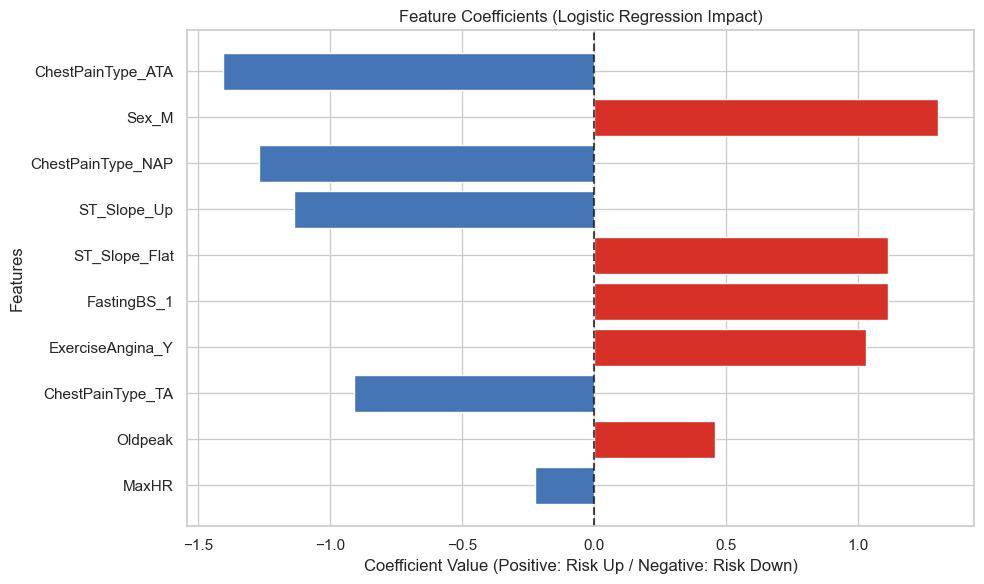

In [11]:
importances = log_reg.coef_[0]
features = X.columns

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

# 顯示前10個
plt.figure(figsize=(10, 6))

colors = ['#d73027' if v > 0 else '#4575b4' for v in feature_importance_df.head(10)['Importance']]

plt.barh(
    y=feature_importance_df.head(10)['Feature'],
    width=feature_importance_df.head(10)['Importance'],
    color=colors
)

plt.title("Feature Coefficients (Logistic Regression Impact)")
plt.xlabel("Coefficient Value (Positive: Risk Up / Negative: Risk Down)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**往右長（正值，藍偏紅）：風險增加因子：**
條形往右邊長的特徵，代表它們與患病機率成正相關
*   Sex_M (男性)：圖中往右最長的條形，代表在此資料集中，男性身份是預測心臟病最強的正向指標

*   ST_Slope_Flat (心電圖平緩斜率) 與FastingBS_1 (空腹血糖異常)：這些生理指標若出現，會顯著拉高患病機率

*   ExerciseAngina_Y (運動誘發心絞痛)：這是一個很明確的發病預兆，權重也非常高

**往左長（負值，深藍偏灰）：風險降低因子：**
條形往左邊長的特徵，代表它們與患病機率成負相關
*   ChestPainType_ATA (典型胸痛)：雖然也是胸痛，但相較於ASY（無症狀），具備ATA特徵的人患病機率反而較低

*   ST_Slope_Up (心電圖上揚斜率)：這是心臟功能良好的強大證據，條形明顯往左

*   MaxHR (最大心率)：最大心率越高的人，心肺功能通常越好，患病機率隨之下降


A. 是否有任何特徵(Features)強烈影響結果？
*   ST_Slope_Up / Flat：邏輯回歸中，ST_Slope_Up通常呈現強烈的負相關（係數為負），代表其為心臟健康的保護因子，反之Flat則代表高患病風險

*   ExerciseAngina_Y：運動引發的心絞痛具備極高的正向權重，是預測患病的第三大關鍵

*   MaxHR與Oldpeak：係數數值顯著，印證了心電圖細節在臨床診斷中不可取代的地位

B. 比較不同模型的性能
*   基準測試 (Baseline)：未受限的單一決策樹呈現嚴重的過擬合，訓練集準確率1.0000與測試集的巨大落差證明其僅在死背數據
*   優化成效 (Logistic Regression)：邏輯回歸 5-Fold 交叉驗證中表現極其穩定，測試集準確率達85.87%，且泛化差距（Gap）縮小至0.51%

C. 討論模型是否遭受「過擬合」(Overfitting)？

*   模型A (決策樹)：存在明顯Overfitting，捕獲的是數據雜訊而非病理規律
*   模型B (邏輯回歸)：透過StandardScaler與Ridge Regression，成功消除了過擬合現象。雖然訓練集分數看似比A低，但測試集分數更高且更穩定

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        77
           1       0.88      0.81      0.84       107

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184

測試集準確率：0.8261
訓練集準確率：0.9932
泛化差距 (Gap)：0.1671
AUC：0.9114


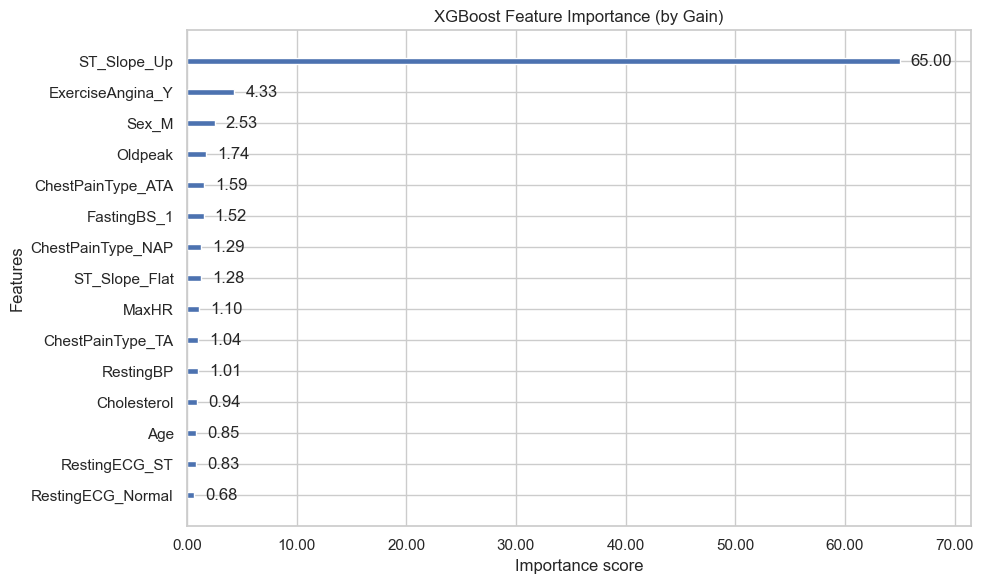

In [12]:
# ========== Homework 4 ==========

#--- XGBoost ---
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. 訓練 XGBoost 模型
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 2. 預測
xgb_pred = xgb_model.predict(X_test)

# 3. 評估
print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print(f"測試集準確率：{accuracy_score(y_test, xgb_pred):.4f}")
print(f"訓練集準確率：{accuracy_score(y_train, xgb_model.predict(X_train)):.4f}")
print(f"泛化差距 (Gap)：{accuracy_score(y_train, xgb_model.predict(X_train)) - accuracy_score(y_test, xgb_pred):.4f}")
print(f"AUC：{roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")

# 4. Feature Importance 圖
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain', ax=ax)

# 將 x 軸數字改為小數點後兩位
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# 將每個 bar 旁邊的數字也改為小數點後兩位
for text in ax.texts:
    try:
        val = float(text.get_text())
        text.set_text(f'{val:.2f}')
    except ValueError:
        pass

plt.title('XGBoost Feature Importance (by Gain)')
plt.tight_layout()
plt.show()

[Grid Search] 最佳參數：{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
[Grid Search] CV 準確率：0.8705
[Grid Search] 訓練集準確率：0.9101
[Grid Search] 測試集準確率：0.8478
[Grid Search] 泛化差距：0.0623

[Random Search] 最佳參數：{'colsample_bytree': np.float64(0.718509402281633), 'learning_rate': np.float64(0.0430533878126005), 'max_depth': 3, 'n_estimators': 120, 'subsample': np.float64(0.7693605922825478)}
[Random Search] CV 準確率：0.8678
[Random Search] 訓練集準確率：0.9114
[Random Search] 測試集準確率：0.8533
[Random Search] 泛化差距：0.0582

[Bayesian Opt] 最佳參數：{'n_estimators': 187, 'max_depth': 3, 'learning_rate': 0.06052231042144902, 'subsample': 0.9697619637158517, 'colsample_bytree': 0.656846891714011}
[Bayesian Opt] 訓練集準確率：0.9292
[Bayesian Opt] 測試集準確率：0.8859
[Bayesian Opt] 泛化差距：0.0433


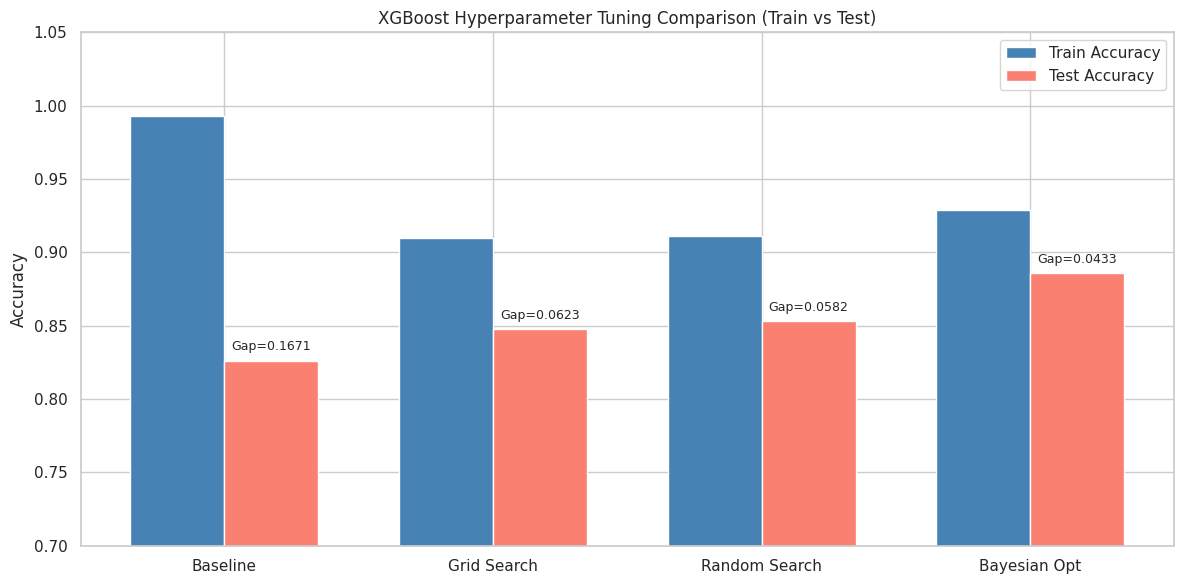

In [13]:
# XGBoost 的 Hyperparameter Tuning code


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint, uniform
import optuna
import warnings
warnings.filterwarnings('ignore')

# ===== 1. Grid Search =====
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_model = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_model.fit(X_train, y_train)
grid_best_score = grid_model.best_score_
grid_test_score = accuracy_score(y_test, grid_model.predict(X_test))
grid_train_score = accuracy_score(y_train, grid_model.predict(X_train))
print(f"[Grid Search] 最佳參數：{grid_model.best_params_}")
print(f"[Grid Search] CV 準確率：{grid_best_score:.4f}")
print(f"[Grid Search] 訓練集準確率：{grid_train_score:.4f}")
print(f"[Grid Search] 測試集準確率：{grid_test_score:.4f}")
print(f"[Grid Search] 泛化差距：{grid_train_score - grid_test_score:.4f}")

# ===== 2. Random Search =====
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}
random_model = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_dist, n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
random_model.fit(X_train, y_train)
random_best_score = random_model.best_score_
random_test_score = accuracy_score(y_test, random_model.predict(X_test))
random_train_score = accuracy_score(y_train, random_model.predict(X_train))
print(f"\n[Random Search] 最佳參數：{random_model.best_params_}")
print(f"[Random Search] CV 準確率：{random_best_score:.4f}")
print(f"[Random Search] 訓練集準確率：{random_train_score:.4f}")
print(f"[Random Search] 測試集準確率：{random_test_score:.4f}")
print(f"[Random Search] 泛化差距：{random_train_score - random_test_score:.4f}")

# ===== 3. Bayesian Optimization (Optuna) =====
def objective(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 200),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
bayes_best_score = study.best_value

bayes_model = XGBClassifier(
    **study.best_params,
    eval_metric='logloss',
    random_state=42
)
bayes_model.fit(X_train, y_train)
bayes_train_score = accuracy_score(y_train, bayes_model.predict(X_train))
bayes_test_score = accuracy_score(y_test, bayes_model.predict(X_test))
print(f"\n[Bayesian Opt] 最佳參數：{study.best_params}")
print(f"[Bayesian Opt] 訓練集準確率：{bayes_train_score:.4f}")
print(f"[Bayesian Opt] 測試集準確率：{bayes_test_score:.4f}")
print(f"[Bayesian Opt] 泛化差距：{bayes_train_score - bayes_test_score:.4f}")

# ===== 4. 比較圖 =====
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # 避免中文亂碼

methods = ['Baseline', 'Grid Search', 'Random Search', 'Bayesian Opt']
train_scores = [0.9932, grid_train_score, random_train_score, bayes_train_score]
test_scores = [0.8261, grid_test_score, random_test_score, bayes_test_score]
gaps = [0.1671, grid_train_score - grid_test_score,
        random_train_score - random_test_score,
        bayes_train_score - bayes_test_score]

x = range(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], train_scores, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], test_scores, width, label='Test Accuracy', color='salmon')

for bar, gap in zip(bars2, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'Gap={gap:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.7, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(methods)
ax.set_ylabel('Accuracy')
ax.set_title('XGBoost Hyperparameter Tuning Comparison (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

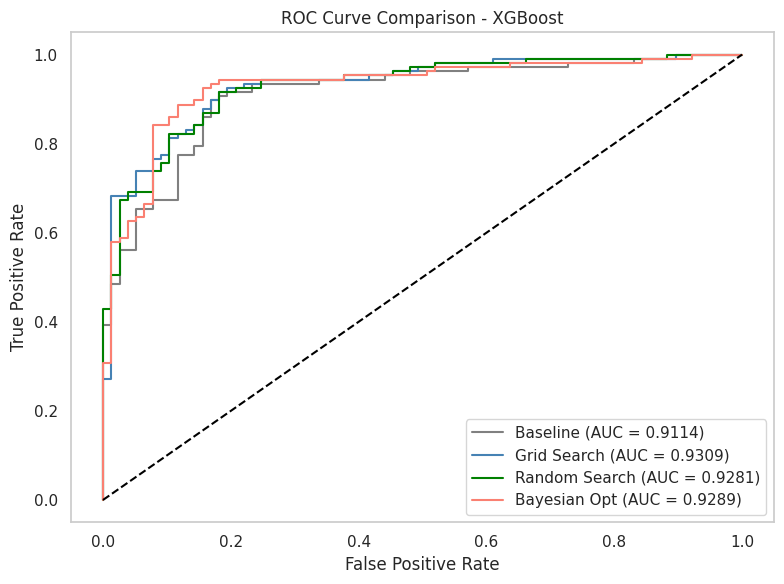

In [14]:
# XGBoost的 ROC Curve

from sklearn.metrics import roc_curve, auc

# ROC Curve 比較圖（Baseline vs 三種調參方法）
plt.rcParams['font.family'] = 'DejaVu Sans'

models_roc = {
    'Baseline': xgb_model,
    'Grid Search': grid_model.best_estimator_,
    'Random Search': random_model.best_estimator_,
    'Bayesian Opt': bayes_model
}

colors = ['gray', 'steelblue', 'green', 'salmon']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models_roc.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color)

plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - XGBoost')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

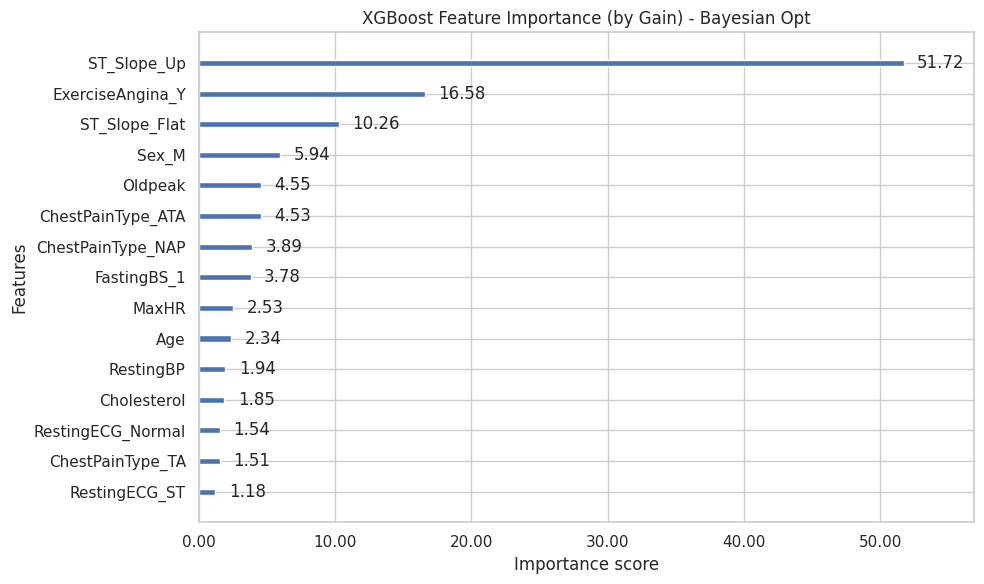

In [15]:
#  Feature Importance 圖
import matplotlib.pyplot as plt
import joblib
from xgboost import plot_importance

# Feature Importance（Bayesian Opt 最佳模型）
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(bayes_model, importance_type='gain', ax=ax)

# 將數字改為小數點後兩位
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
for text in ax.texts:
    try:
        val = float(text.get_text())
        text.set_text(f'{val:.2f}')
    except ValueError:
        pass

plt.title('XGBoost Feature Importance (by Gain) - Bayesian Opt')
plt.tight_layout()
plt.show()

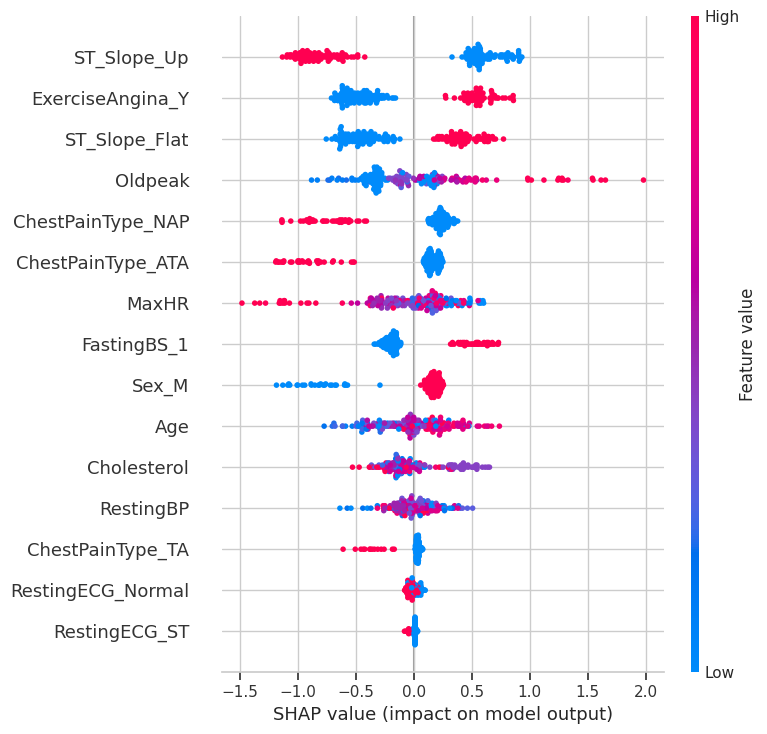

In [16]:
import shap

# 將資料轉成 float64 讓 SHAP 可以處理
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# 使用 Bayesian Opt 的最佳模型做 SHAP 分析
explainer = shap.Explainer(bayes_model, X_train_shap)
shap_values = explainer(X_test_shap)

# Summary Plot
shap.summary_plot(shap_values, X_test_shap)

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, bayes_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        77
           1       0.91      0.89      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Neural Network ===
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

測試集準確率：0.8696
訓練集準確率：0.9019
泛化差距 (Gap)：0.0323
AUC：0.9273


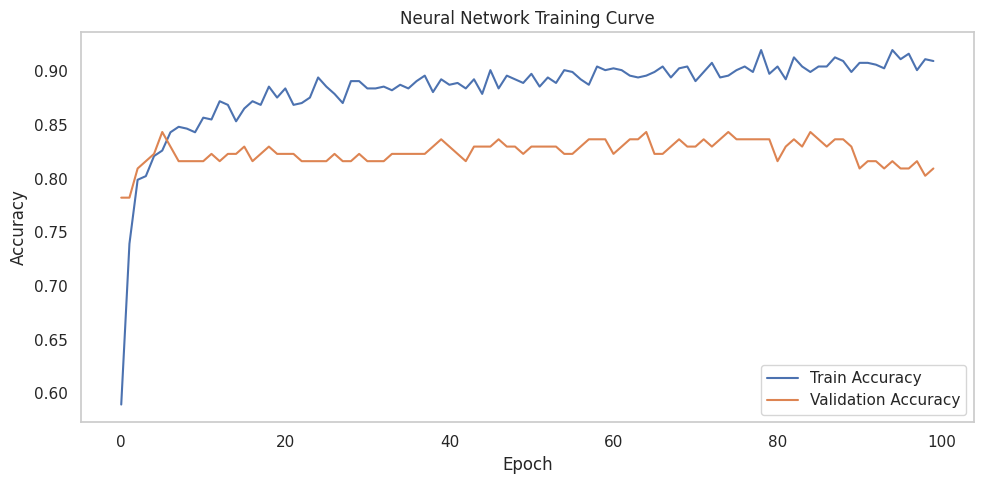

In [18]:
# --- Neural_Network ---

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# 1. 建立模型
nn_model = Sequential()
nn_model.add(Input(shape=(X_train.shape[1],)))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dropout(0.3))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dropout(0.3))
nn_model.add(Dense(1, activation='sigmoid'))

# 2. 編譯模型
nn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

nn_model.summary()

# 3. 訓練模型
history = nn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# 4. 評估
nn_pred = (nn_model.predict(X_test) > 0.5).astype(int)
nn_train_pred = (nn_model.predict(X_train) > 0.5).astype(int)
nn_prob = nn_model.predict(X_test)

print("=== Neural Network ===")
print(classification_report(y_test, nn_pred))
print(f"測試集準確率：{accuracy_score(y_test, nn_pred):.4f}")
print(f"訓練集準確率：{accuracy_score(y_train, nn_train_pred):.4f}")
print(f"泛化差距 (Gap)：{accuracy_score(y_train, nn_train_pred) - accuracy_score(y_test, nn_pred):.4f}")
print(f"AUC：{roc_auc_score(y_test, nn_prob):.4f}")

# 5. Training Curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

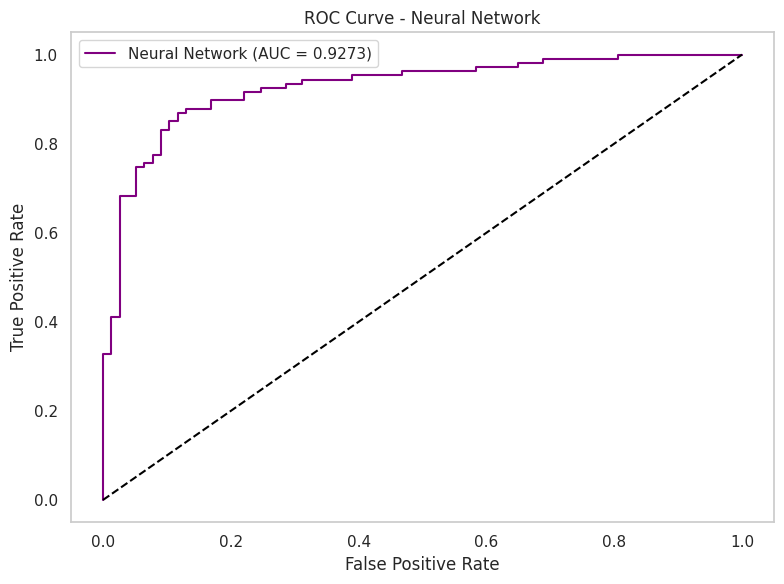

In [19]:
# Neural Network ROC Curve

from sklearn.metrics import roc_curve, auc


fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {roc_auc_nn:.4f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Neural Network')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

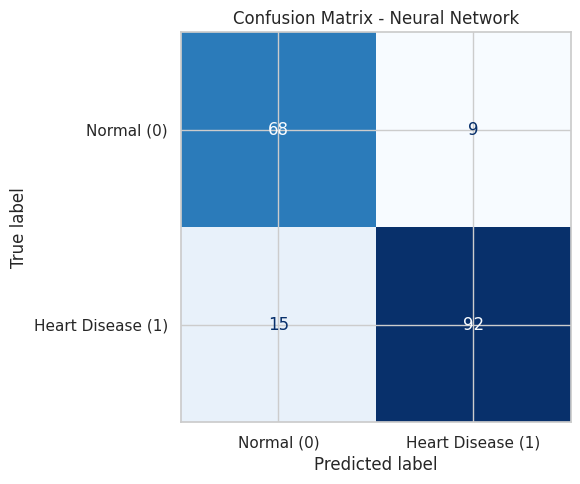

In [20]:
# Neural Network Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, nn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Heart Disease (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.tight_layout()
plt.show()

最佳參數：{'n_layers': 3, 'units': 64, 'dropout_rate': 0.15396900965299212, 'learning_rate': 0.0053249363733188304}
最佳 CV 準確率：0.9496
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

=== Neural Network (Tuned) ===
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        77
           1       0.88      0.80      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184

測試集準確率：0.8207
訓練集準確率：0.9564
泛化差距 (Gap)：0.1358
AUC：0.8855


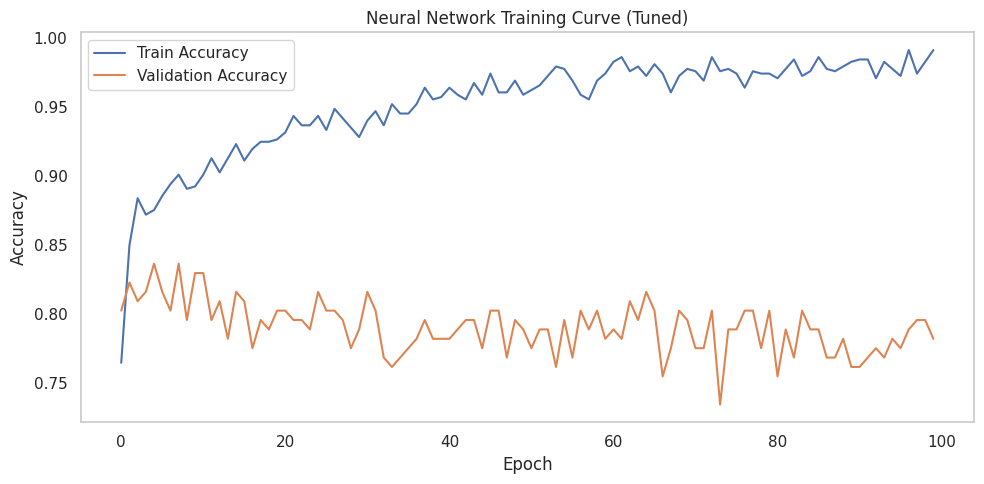

In [21]:
# Neural Network Hyperparameter Tuning

import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def objective_nn(trial):
    # 搜尋範圍
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_categorical('units', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # 建立模型
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for _ in range(n_layers):
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    _, val_acc = model.evaluate(X_train, y_train, verbose=0)
    return val_acc

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_nn = optuna.create_study(direction='maximize')
study_nn.optimize(objective_nn, n_trials=20)

print(f"最佳參數：{study_nn.best_params}")
print(f"最佳 CV 準確率：{study_nn.best_value:.4f}")

# 用最佳參數重新訓練
best = study_nn.best_params
nn_best = Sequential()
nn_best.add(Input(shape=(X_train.shape[1],)))
for _ in range(best['n_layers']):
    nn_best.add(Dense(best['units'], activation='relu'))
    nn_best.add(Dropout(best['dropout_rate']))
nn_best.add(Dense(1, activation='sigmoid'))

nn_best.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=best['learning_rate']),
    metrics=['accuracy']
)

history_best = nn_best.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# 評估
nn_best_pred = (nn_best.predict(X_test) > 0.5).astype(int)
nn_best_train_pred = (nn_best.predict(X_train) > 0.5).astype(int)
nn_best_prob = nn_best.predict(X_test)

print("\n=== Neural Network (Tuned) ===")
print(classification_report(y_test, nn_best_pred))
print(f"測試集準確率：{accuracy_score(y_test, nn_best_pred):.4f}")
print(f"訓練集準確率：{accuracy_score(y_train, nn_best_train_pred):.4f}")
print(f"泛化差距 (Gap)：{accuracy_score(y_train, nn_best_train_pred) - accuracy_score(y_test, nn_best_pred):.4f}")
print(f"AUC：{roc_auc_score(y_test, nn_best_prob):.4f}")

# Training Curve
plt.figure(figsize=(10, 5))
plt.plot(history_best.history['accuracy'], label='Train Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Curve (Tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

最佳參數：{'n_layers': 3, 'units': 64, 'dropout_rate': 0.40001666632926836, 'learning_rate': 0.0009660204266296703}
最佳 Val 準確率：0.8639
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

=== Neural Network (Tuned) ===
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        77
           1       0.82      0.83      0.82       107

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

測試集準確率：0.7935
訓練集準確率：0.8324
泛化差距 (Gap)：0.0389
AUC：0.8735


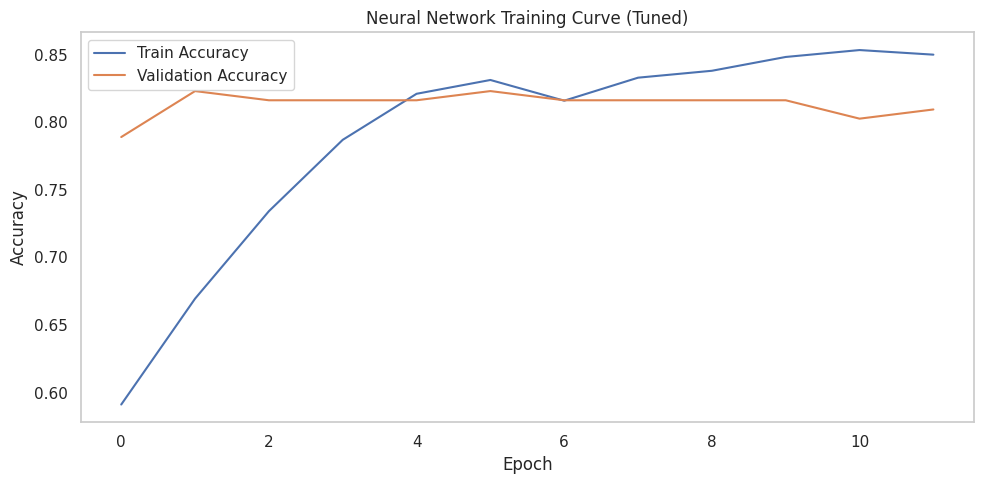

In [22]:
# 調參後反而更差了。Training Curve 也顯示 Train 和 Validation 差距越來越大，明顯 overfitting。
# 因為 Optuna 搜尋時是用訓練集準確率當目標，所以找到的參數傾向於死背訓練資料。把 objective 改成用 validation accuracy 來優化：

import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def objective_nn(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_categorical('units', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for _ in range(n_layers):
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    # 加入 EarlyStopping 避免過擬合
    early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    # 改用 val_accuracy 當優化目標
    return max(history.history['val_accuracy'])

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_nn = optuna.create_study(direction='maximize')
study_nn.optimize(objective_nn, n_trials=20)

print(f"最佳參數：{study_nn.best_params}")
print(f"最佳 Val 準確率：{study_nn.best_value:.4f}")

# 用最佳參數重新訓練
best = study_nn.best_params
nn_best = Sequential()
nn_best.add(Input(shape=(X_train.shape[1],)))
for _ in range(best['n_layers']):
    nn_best.add(Dense(best['units'], activation='relu'))
    nn_best.add(Dropout(best['dropout_rate']))
nn_best.add(Dense(1, activation='sigmoid'))

nn_best.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=best['learning_rate']),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history_best = nn_best.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

# 評估
nn_best_pred = (nn_best.predict(X_test) > 0.5).astype(int)
nn_best_train_pred = (nn_best.predict(X_train) > 0.5).astype(int)
nn_best_prob = nn_best.predict(X_test)

print("\n=== Neural Network (Tuned) ===")
print(classification_report(y_test, nn_best_pred))
print(f"測試集準確率：{accuracy_score(y_test, nn_best_pred):.4f}")
print(f"訓練集準確率：{accuracy_score(y_train, nn_best_train_pred):.4f}")
print(f"泛化差距 (Gap)：{accuracy_score(y_train, nn_best_train_pred) - accuracy_score(y_test, nn_best_pred):.4f}")
print(f"AUC：{roc_auc_score(y_test, nn_best_prob):.4f}")

# Training Curve
plt.figure(figsize=(10, 5))
plt.plot(history_best.history['accuracy'], label='Train Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Curve (Tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

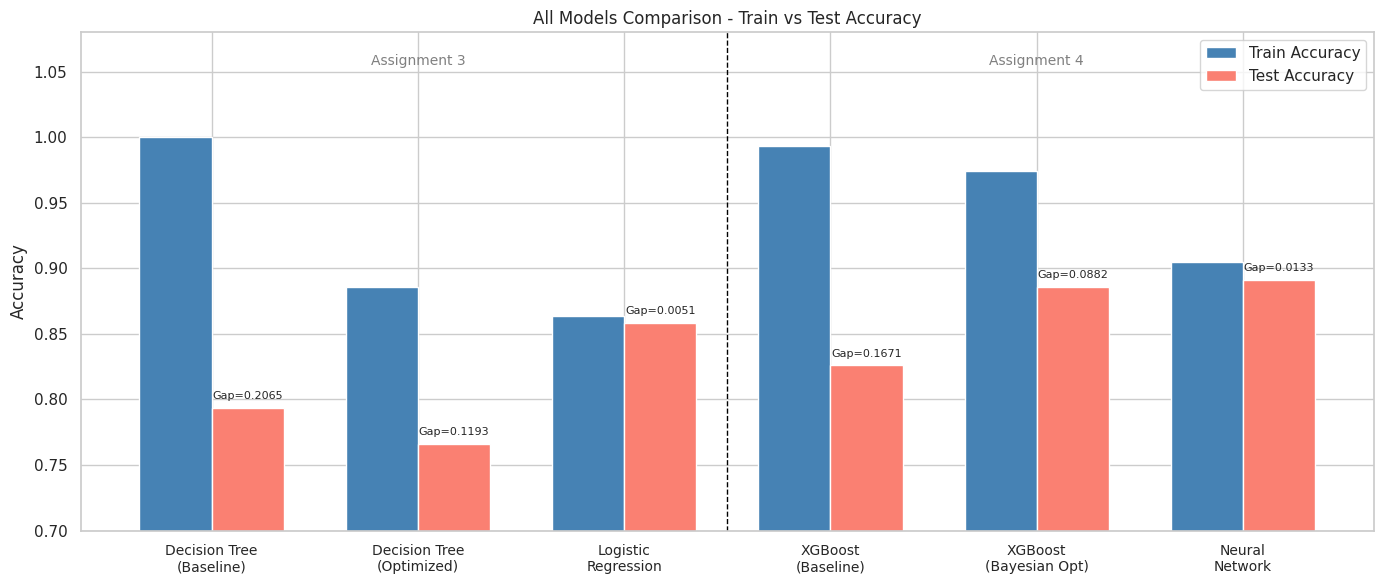

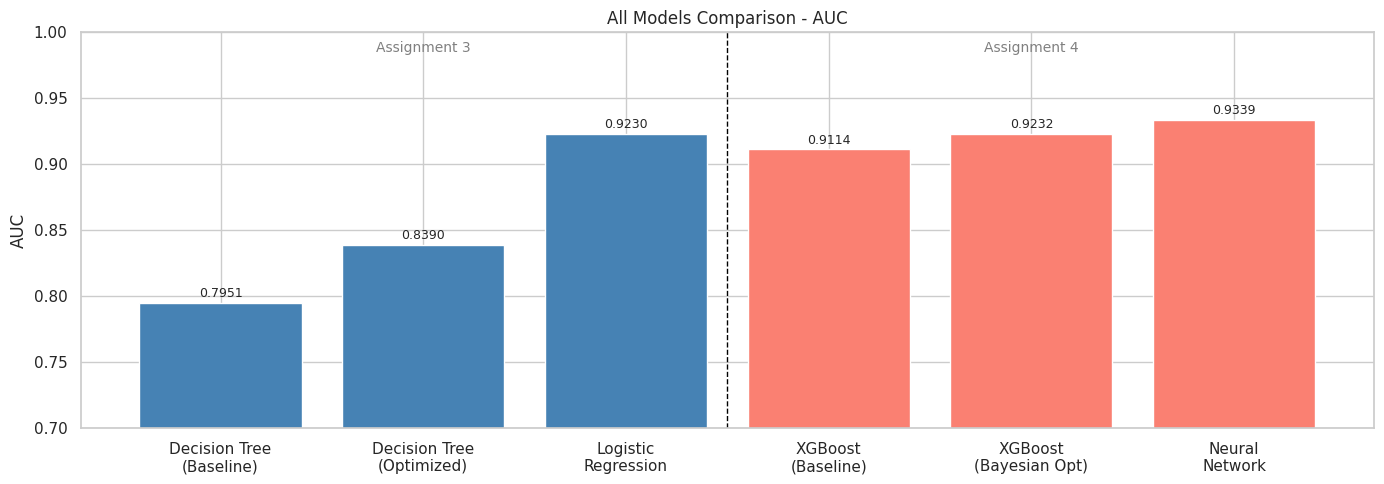

In [23]:
# ===== 所有模型總比較 =====

models_all = {
    'Decision Tree\n(Baseline)':  {'train': 1.0000, 'test': 0.7935, 'auc': 0.7951},
    'Decision Tree\n(Optimized)': {'train': 0.8856, 'test': 0.7663, 'auc': 0.8390},
    'Logistic\nRegression':       {'train': 0.8638, 'test': 0.8587, 'auc': 0.9230},
    'XGBoost\n(Baseline)':        {'train': 0.9932, 'test': 0.8261, 'auc': 0.9114},
    'XGBoost\n(Bayesian Opt)':    {'train': 0.9741, 'test': 0.8859, 'auc': 0.9232},
    'Neural\nNetwork':            {'train': 0.9046, 'test': 0.8913, 'auc': 0.9339},
}

names = list(models_all.keys())
train_scores = [v['train'] for v in models_all.values()]
test_scores  = [v['test']  for v in models_all.values()]
auc_scores   = [v['auc']   for v in models_all.values()]
gaps = [t - s for t, s in zip(train_scores, test_scores)]

x = range(len(names))
width = 0.35

# --- 圖一：Train vs Test Accuracy ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], train_scores, width, label='Train Accuracy', color='steelblue')
ax.bar([i + width/2 for i in x], test_scores,  width, label='Test Accuracy',  color='salmon')

for i, (bar_x, gap, test) in enumerate(zip(x, gaps, test_scores)):
    ax.text(bar_x + width/2, test + 0.005,
            f'Gap={gap:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0.7, 1.08)
ax.set_xticks(list(x))
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('All Models Comparison - Train vs Test Accuracy')
ax.legend()
ax.axvline(x=2.5, color='black', linestyle='--', linewidth=1)
ax.text(1.0, 1.055, 'Assignment 3', ha='center', fontsize=10, color='gray')
ax.text(4.0, 1.055, 'Assignment 4', ha='center', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

# --- 圖二：AUC 比較 ---
colors = ['steelblue', 'steelblue', 'steelblue', 'salmon', 'salmon', 'salmon']
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, auc_scores, color=colors)

for bar, auc_val in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{auc_val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.7, 1.0)
ax.set_ylabel('AUC')
ax.set_title('All Models Comparison - AUC')
ax.axvline(x=2.5, color='black', linestyle='--', linewidth=1)
ax.text(1.0, 0.985, 'Assignment 3', ha='center', fontsize=10, color='gray')
ax.text(4.0, 0.985, 'Assignment 4', ha='center', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

In [27]:
# Neural Network Model Dump
import joblib
from tensorflow.keras.models import load_model

# 儲存 Neural Network 最佳模型（Baseline）
nn_model.save('nn_best_model.keras')

# Scaler 仍用 joblib 儲存
joblib.dump(scaler, 'scaler.pkl')

print("模型已儲存：")
print("  - nn_best_model.keras（Neural Network Baseline）")
print("  - scaler.pkl（StandardScaler）")

模型已儲存：
  - nn_best_model.keras（Neural Network Baseline）
  - scaler.pkl（StandardScaler）


In [28]:
# 儲存最佳 XGBoost 模型（Bayesian Opt）
joblib.dump(bayes_model, 'xgb_best_model.pkl')

print("模型已儲存：")
print("  - xgb_best_model.pkl（XGBoost Bayesian Opt）")

模型已儲存：
  - xgb_best_model.pkl（XGBoost Bayesian Opt）


In [29]:
#載入 UCI Cleveland（產生 df_ext）
import pandas as pd
import numpy as np

url_cleveland = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
col_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
             'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_ext = pd.read_csv(url_cleveland, names=col_names, na_values='?')

print(f"原始資料筆數：{df_ext.shape[0]}")
print(f"缺失值：\n{df_ext.isnull().sum()}")

# 先刪除 ca 和 thal 整個欄位
df_ext.drop(['ca', 'thal'], axis=1, inplace=True)

# 刪除缺失值（刪除 ca 和 thal 後已無缺失值）
df_ext.dropna(inplace=True)
print(f"\n清洗後資料筆數：{df_ext.shape[0]}")

# 欄位對應轉換
df_ext['Sex'] = df_ext['sex'].map({1: 'M', 0: 'F'})
df_ext['ChestPainType'] = df_ext['cp'].map({1: 'TA', 2: 'ATA', 3: 'NAP', 4: 'ASY'})
df_ext['RestingECG'] = df_ext['restecg'].map({0: 'Normal', 1: 'ST', 2: 'LVH'})
df_ext['ExerciseAngina'] = df_ext['exang'].map({1: 'Y', 0: 'N'})
df_ext['ST_Slope'] = df_ext['slope'].map({1: 'Up', 2: 'Flat', 3: 'Down'})
df_ext['HeartDisease'] = (df_ext['target'] > 0).astype(int)

# 整理欄位名稱
df_ext.rename(columns={
    'age': 'Age',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBS',
    'thalach': 'MaxHR',
    'oldpeak': 'Oldpeak'
}, inplace=True)

# 刪除原始欄位
df_ext.drop(['sex', 'cp', 'restecg', 'exang', 'slope', 'target'], axis=1, inplace=True)

# 異常值處理
df_ext['Cholesterol'] = df_ext['Cholesterol'].replace(0, df_ext['Cholesterol'].median())
df_ext['RestingBP'] = df_ext['RestingBP'].replace(0, df_ext['RestingBP'].median())

print("\n轉換後欄位：")
print(df_ext.head())
print(f"\nHeartDisease 分布：\n{df_ext['HeartDisease'].value_counts()}")

原始資料筆數：303
缺失值：
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

清洗後資料筆數：303

轉換後欄位：
    Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak Sex ChestPainType  \
0  63.0      145.0        233.0        1.0  150.0      2.3   M            TA   
1  67.0      160.0        286.0        0.0  108.0      1.5   M           ASY   
2  67.0      120.0        229.0        0.0  129.0      2.6   M           ASY   
3  37.0      130.0        250.0        0.0  187.0      3.5   M           NAP   
4  41.0      130.0        204.0        0.0  172.0      1.4   F           ATA   

  RestingECG ExerciseAngina ST_Slope  HeartDisease  
0        LVH              N     Down             0  
1        LVH              Y     Flat             1  
2        LVH              Y     Flat             1  
3     Normal              N     Down             0  
4       

模型載入成功！
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

=== 外部驗證結果（UCI Cleveland）- Neural Network ===
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       164
           1       0.82      0.86      0.84       139

    accuracy                           0.85       303
   macro avg       0.85      0.85      0.85       303
weighted avg       0.85      0.85      0.85       303

Accuracy：0.8482
AUC：0.9224


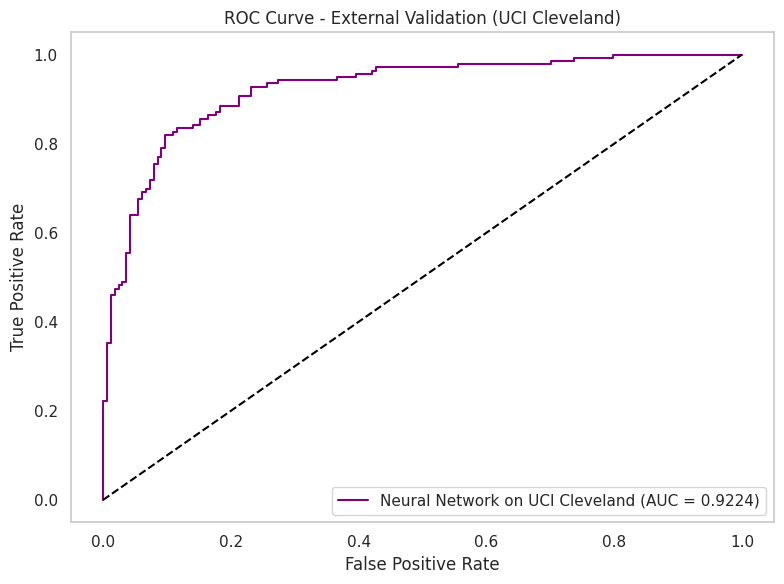

In [30]:
#Neural Network 外部驗證
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import joblib

# 載入模型與 Scaler
nn_loaded = load_model('nn_best_model.keras')
scaler_loaded = joblib.load('scaler.pkl')
print("模型載入成功！")

numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X_ext = df_ext.drop('HeartDisease', axis=1)
y_ext = df_ext['HeartDisease']

X_ext = pd.get_dummies(X_ext, columns=categorical_features, drop_first=True)

for col in X_train.columns.tolist():
    if col not in X_ext.columns:
        X_ext[col] = 0
X_ext = X_ext[X_train.columns.tolist()]

X_ext[numerical_features] = scaler_loaded.transform(X_ext[numerical_features])

y_ext_prob = nn_loaded.predict(X_ext)
y_ext_pred = (y_ext_prob > 0.5).astype(int)

print("\n=== 外部驗證結果（UCI Cleveland）- Neural Network ===")
print(classification_report(y_ext, y_ext_pred))
print(f"Accuracy：{accuracy_score(y_ext, y_ext_pred):.4f}")
print(f"AUC：{roc_auc_score(y_ext, y_ext_prob):.4f}")

fpr, tpr, _ = roc_curve(y_ext, y_ext_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Neural Network on UCI Cleveland (AUC = {roc_auc:.4f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - External Validation (UCI Cleveland)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

模型載入成功！

=== 外部驗證結果（UCI Cleveland）- XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       164
           1       0.90      0.82      0.86       139

    accuracy                           0.87       303
   macro avg       0.88      0.87      0.87       303
weighted avg       0.88      0.87      0.87       303

Accuracy：0.8746
AUC：0.9404


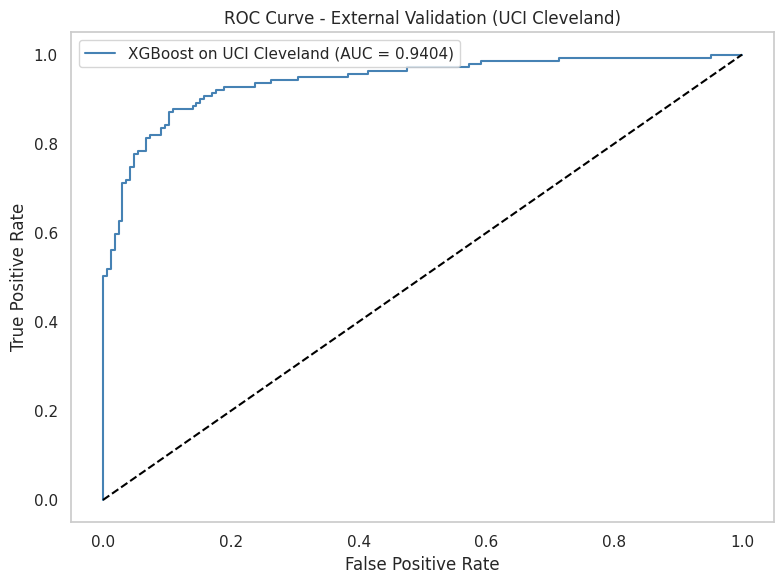

In [31]:
#XGBoost 外部驗證
# 載入 XGBoost 模型
model_loaded = joblib.load('xgb_best_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')
print("模型載入成功！")

X_ext = df_ext.drop('HeartDisease', axis=1)
y_ext = df_ext['HeartDisease']

X_ext = pd.get_dummies(X_ext, columns=categorical_features, drop_first=True)

for col in X_train.columns.tolist():
    if col not in X_ext.columns:
        X_ext[col] = 0
X_ext = X_ext[X_train.columns.tolist()]

X_ext[numerical_features] = scaler_loaded.transform(X_ext[numerical_features])

y_ext_pred = model_loaded.predict(X_ext)
y_ext_prob = model_loaded.predict_proba(X_ext)[:, 1]

print("\n=== 外部驗證結果（UCI Cleveland）- XGBoost ===")
print(classification_report(y_ext, y_ext_pred))
print(f"Accuracy：{accuracy_score(y_ext, y_ext_pred):.4f}")
print(f"AUC：{roc_auc_score(y_ext, y_ext_prob):.4f}")

fpr, tpr, _ = roc_curve(y_ext, y_ext_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost on UCI Cleveland (AUC = {roc_auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - External Validation (UCI Cleveland)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()